<a href="https://colab.research.google.com/github/PritsP/Quant-Project/blob/main/notebooks/project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import norm
from scipy.optimize import brentq
import matplotlib.pyplot as plt

In [ ]:
def bsm_call_price(S, K, T, r, sigma):
    """
    Black-Scholes-Merton price of a European call option.

    S     : current stock price
    K     : strike price
    T     : time to expiry, in years
    r     : risk-free rate (annualized, e.g. 0.05 for 5%)
    sigma : volatility (annualized, e.g. 0.20 for 20%)
    """
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    return price


def bsm_put_price(S, K, T, r, sigma):
    """
    Black-Scholes-Merton price of a European put option.
    Derived via put-call parity rather than rewriting from scratch:
    P = C - S + K*e^(-rT)
    """
    call = bsm_call_price(S, K, T, r, sigma)
    price = call - S + K * np.exp(-r * T)
    return price

    # A 3-month ATM call on a $100 stock, 5% rates, 20% vol
test_call = bsm_call_price(S=100, K=100, T=0.25, r=0.05, sigma=0.20)
test_put  = bsm_put_price(S=100, K=100, T=0.25, r=0.05, sigma=0.20)

print(f"Call price: {test_call:.4f}")
print(f"Put price:  {test_put:.4f}")

Call price: 4.6150
Put price:  3.3728


In [ ]:
def delta(S, K, T, r, sigma, option_type='call'):
    """Rate of change of option price with respect to a $1 move in S."""
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    if option_type == 'call':
        return norm.cdf(d1)
    elif option_type == 'put':
        return norm.cdf(d1) - 1


def gamma(S, K, T, r, sigma):
    """Rate of change of delta with respect to a $1 move in S. Same for calls and puts."""
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return norm.pdf(d1) / (S * sigma * np.sqrt(T))


def vega(S, K, T, r, sigma):
    """Rate of change of option price per 1.0 (100%) change in vol.
    Convention: many traders quote this per 1% vol move, so divide by 100 if needed."""
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return S * norm.pdf(d1) * np.sqrt(T)


def theta(S, K, T, r, sigma, option_type='call'):
    """Rate of change of option price per day passing. Returned as annualized;
    divide by 365 for the daily figure traders actually look at."""
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    term1 = -(S * norm.pdf(d1) * sigma) / (2 * np.sqrt(T))

    if option_type == 'call':
        term2 = -r * K * np.exp(-r * T) * norm.cdf(d2)
        return term1 + term2
    elif option_type == 'put':
        term2 = r * K * np.exp(-r * T) * norm.cdf(-d2)
        return term1 + term2


def rho(S, K, T, r, sigma, option_type='call'):
    """Rate of change of option price per 1.0 (100%) change in interest rate."""
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if option_type == 'call':
        return K * T * np.exp(-r * T) * norm.cdf(d2)
    elif option_type == 'put':
        return -K * T * np.exp(-r * T) * norm.cdf(-d2)

print(f"Delta: {delta(100, 100, 0.25, 0.05, 0.20, 'call'):.4f}")
print(f"Gamma: {gamma(100, 100, 0.25, 0.05, 0.20):.4f}")
print(f"Vega:  {vega(100, 100, 0.25, 0.05, 0.20):.4f}")
print(f"Theta: {theta(100, 100, 0.25, 0.05, 0.20, 'call') / 365:.4f}  (daily)")

Delta: 0.5695
Gamma: 0.0393
Vega:  19.6440
Theta: -0.0287  (daily)


In [ ]:
def implied_vol(market_price, S, K, T, r, option_type='call',
                 initial_guess=0.20, max_iterations=100, tolerance=1e-6):
    """
    Solves for the implied volatility that makes the BSM price
    equal to the observed market price.

    Uses Newton-Raphson first; falls back to Brent's method if
    Newton-Raphson fails to converge or vega is too small.
    """
    sigma = initial_guess

    # --- Attempt 1: Newton-Raphson ---
    for i in range(max_iterations):
        if option_type == 'call':
            price = bsm_call_price(S, K, T, r, sigma)
        else:
            price = bsm_put_price(S, K, T, r, sigma)

        diff = price - market_price

        if abs(diff) < tolerance:
            return sigma  # converged

        v = vega(S, K, T, r, sigma)

        if v < 1e-8:
            break  # vega too small — Newton-Raphson will be unstable here

        sigma = sigma - diff / v

        if sigma <= 0 or sigma > 5:
            break  # sigma went somewhere nonsensical, abandon and fall back

    # --- Attempt 2: Brent's method (fallback) ---
    def objective(s):
        if option_type == 'call':
            return bsm_call_price(S, K, T, r, s) - market_price
        else:
            return bsm_put_price(S, K, T, r, s) - market_price

    try:
        return brentq(objective, 1e-6, 5.0, xtol=tolerance)
    except ValueError:
        # Brent's method needs the objective to have opposite signs at the
        # two endpoints — if it doesn't, no solution exists in that range
        return np.nan

 # Generate a price with a known vol, then solve backwards and confirm we recover it
true_sigma = 0.25
synthetic_price = bsm_call_price(S=100, K=105, T=0.5, r=0.05, sigma=true_sigma)

recovered_sigma = implied_vol(synthetic_price, S=100, K=105, T=0.5, r=0.05, option_type='call')

print(f"True vol:      {true_sigma:.4f}")
print(f"Recovered vol: {recovered_sigma:.4f}")

True vol:      0.2500
Recovered vol: 0.2500


In [ ]:
# Deep OTM option — vega is tiny here, this tests your fallback
deep_otm_price = bsm_call_price(S=100, K=200, T=0.1, r=0.05, sigma=0.20)
iv_deep_otm = implied_vol(deep_otm_price, S=100, K=200, T=0.1, r=0.05, option_type='call')
print(f"Deep OTM recovered vol: {iv_deep_otm:.4f}")

# Near-zero time to expiry
near_expiry_price = bsm_call_price(S=100, K=100, T=0.001, r=0.05, sigma=0.20)
iv_near_expiry = implied_vol(near_expiry_price, S=100, K=100, T=0.001, r=0.05, option_type='call')
print(f"Near-expiry recovered vol: {iv_near_expiry:.4f}")


Deep OTM recovered vol: 0.2000
Near-expiry recovered vol: 0.2000


In [ ]:
# ============================================================
# -- upload, clean, compute IV, validate
# ============================================================

from google.colab import files
import pandas as pd
import numpy as np
import io
from datetime import datetime
from scipy.stats import norm
from scipy.optimize import brentq

# ---- BSM FUNCTIONS ----

def bsm_call_price(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

def bsm_put_price(S, K, T, r, sigma):
    call = bsm_call_price(S, K, T, r, sigma)
    return call - S + K * np.exp(-r * T)

def vega(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return S * norm.pdf(d1) * np.sqrt(T)

def implied_vol(market_price, S, K, T, r, option_type='call',
                initial_guess=0.20, max_iterations=100, tolerance=1e-6):
    sigma = initial_guess
    for i in range(max_iterations):
        if option_type == 'call':
            price = bsm_call_price(S, K, T, r, sigma)
        else:
            price = bsm_put_price(S, K, T, r, sigma)
        diff = price - market_price
        if abs(diff) < tolerance:
            return sigma
        v = vega(S, K, T, r, sigma)
        if v < 1e-8:
            break
        sigma = sigma - diff / v
        if sigma <= 0 or sigma > 5:
            break
    # Brent's fallback
    def objective(s):
        if option_type == 'call':
            return bsm_call_price(S, K, T, r, s) - market_price
        else:
            return bsm_put_price(S, K, T, r, s) - market_price
    try:
        return brentq(objective, 1e-6, 5.0, xtol=tolerance)
    except:
        return np.nan

# ---- UPLOAD AND LOAD ----

uploaded = files.upload()
filename = list(uploaded.keys())[0]
content = uploaded[filename].decode('utf-8')
df_raw = pd.read_csv(io.StringIO(content), skiprows=3)
print(f"Loaded {df_raw.shape[0]} rows, {df_raw.shape[1]} columns")

# ---- MARKET INPUTS ----

S = 747.41   # SPY spot price from file header
r = 0.053    # 3-month Treasury yield, annualized
today = datetime.today()

# ---- COMPUTE T (time to expiry in years) ----

df_raw['Expiry_dt'] = pd.to_datetime(df_raw['Expiration Date'])
df_raw['T'] = (df_raw['Expiry_dt'] - today).dt.days / 365

# ---- SPLIT CALLS AND PUTS ----

calls = df_raw[[
    'Expiration Date', 'Expiry_dt', 'T', 'Strike',
    'Calls', 'Last Sale', 'Net', 'Bid', 'Ask', 'Volume',
    'IV', 'Delta', 'Gamma', 'Open Interest'
]].copy()
calls.columns = [
    'Expiration Date', 'Expiry_dt', 'T', 'Strike',
    'Contract', 'Last Sale', 'Net', 'Bid', 'Ask', 'Volume',
    'IV_cboe', 'Delta_cboe', 'Gamma_cboe', 'Open Interest'
]
calls['option_type'] = 'call'

puts = df_raw[[
    'Expiration Date', 'Expiry_dt', 'T', 'Strike',
    'Puts', 'Last Sale.1', 'Net.1', 'Bid.1', 'Ask.1', 'Volume.1',
    'IV.1', 'Delta.1', 'Gamma.1', 'Open Interest.1'
]].copy()
puts.columns = [
    'Expiration Date', 'Expiry_dt', 'T', 'Strike',
    'Contract', 'Last Sale', 'Net', 'Bid', 'Ask', 'Volume',
    'IV_cboe', 'Delta_cboe', 'Gamma_cboe', 'Open Interest'
]
puts['option_type'] = 'put'

options = pd.concat([calls, puts], ignore_index=True)
print(f"Total options before cleaning: {len(options)} ({len(calls)} calls, {len(puts)} puts)")

# ---- DATA CLEANING ----

options['Mid'] = (options['Bid'] + options['Ask']) / 2
options['Moneyness'] = options['Strike'] / S

n = len(options)
options = options[options['Volume'] > 0]
print(f"After zero volume filter:      {len(options)} (removed {n - len(options)})")

n = len(options)
options = options[options['Open Interest'] > 10]
print(f"After low open interest filter:{len(options)} (removed {n - len(options)})")

n = len(options)
options = options[options['Bid'] > 0]
print(f"After zero bid filter:         {len(options)} (removed {n - len(options)})")

n = len(options)
options = options[options['T'] > 7/365]
print(f"After short dated filter:      {len(options)} (removed {n - len(options)})")

n = len(options)
options = options[(options['Moneyness'] >= 0.80) & (options['Moneyness'] <= 1.20)]
print(f"After deep ITM/OTM filter:     {len(options)} (removed {n - len(options)})")

options = options.reset_index(drop=True)
print(f"\nFinal clean dataset: {len(options)} options")

# ---- COMPUTE IMPLIED VOL ----

def compute_iv_row(row):
    try:
        return implied_vol(
            market_price = row['Mid'],
            S            = S,
            K            = row['Strike'],
            T            = row['T'],
            r            = r,
            option_type  = row['option_type']
        )
    except:
        return np.nan

options['IV_computed'] = options.apply(compute_iv_row, axis=1)

n_before = len(options)
options = options.dropna(subset=['IV_computed'])
print(f"IV computed successfully for {len(options)}/{n_before} options")

# ---- VALIDATE AGAINST CBOE ----

options['IV_diff'] = options['IV_computed'] - options['IV_cboe']
options['IV_diff_pct'] = (options['IV_diff'] / options['IV_cboe']) * 100

print("\nIV Comparison — Your Solver vs CBOE:")
print(options[[
    'Expiration Date', 'Strike', 'option_type',
    'Mid', 'IV_cboe', 'IV_computed', 'IV_diff_pct'
]].to_string())

print(f"\nMean absolute difference: {options['IV_diff'].abs().mean():.6f}")
print(f"Max absolute difference:  {options['IV_diff'].abs().max():.6f}")

Saving spy_quotedata august.csv to spy_quotedata august.csv
Saving spy_quotedata december.csv to spy_quotedata december.csv
Saving spy_quotedata july.csv to spy_quotedata july.csv
Saving spy_quotedata october.csv to spy_quotedata october.csv
Saving spy_quotedata september.csv to spy_quotedata september.csv
Loaded 80 rows, 22 columns
Total options before cleaning: 160 (80 calls, 80 puts)
After zero volume filter:      154 (removed 6)
After low open interest filter:146 (removed 8)
After zero bid filter:         146 (removed 0)
After short dated filter:      107 (removed 39)
After deep ITM/OTM filter:     107 (removed 0)

Final clean dataset: 107 options
IV computed successfully for 107/107 options

IV Comparison — Your Solver vs CBOE:
     Expiration Date  Strike option_type     Mid  IV_cboe  IV_computed  IV_diff_pct
0    Fri Aug 14 2026   735.0        call  22.605   0.1493     0.322879   116.261735
1    Fri Aug 14 2026   738.0        call  20.465   0.1461     0.316176   116.410788
2    

In [ ]:
from google.colab import files
import pandas as pd
import numpy as np
import io
from datetime import datetime
from scipy.stats import norm
from scipy.optimize import brentq

# ---- UPLOAD ALL 5 FILES AT ONCE ----
# When the picker opens, select all 5 CSVs at the same time
# (hold Cmd on Mac to select multiple files)

uploaded = files.upload()

# ---- LOAD AND COMBINE ----

S = 744.78  # update this to whatever SPY's current price shows on CBOE today
r = 0.053
today = datetime.today()

all_dfs = []

for filename, content in uploaded.items():
    print(f"Loading {filename}...")

    # Same loading logic as before
    text = content.decode('utf-8')
    df = pd.read_csv(io.StringIO(text), skiprows=3)

    # Add a column so we know which file each row came from
    df['source_file'] = filename
    all_dfs.append(df)

# Stack all files into one DataFrame
df_raw = pd.concat(all_dfs, ignore_index=True)

print(f"\nTotal rows across all files: {len(df_raw)}")
print(f"Columns: {df_raw.columns.tolist()}")
print(f"\nUnique expiry dates found:")
print(df_raw['Expiration Date'].value_counts().sort_index())

Saving spy_quotedata august.csv to spy_quotedata august (1).csv
Saving spy_quotedata december.csv to spy_quotedata december (1).csv
Saving spy_quotedata july.csv to spy_quotedata july (1).csv
Saving spy_quotedata october.csv to spy_quotedata october (1).csv
Saving spy_quotedata september.csv to spy_quotedata september (1).csv
Loading spy_quotedata august (1).csv...
Loading spy_quotedata december (1).csv...
Loading spy_quotedata july (1).csv...
Loading spy_quotedata october (1).csv...
Loading spy_quotedata september (1).csv...

Total rows across all files: 480
Columns: ['Expiration Date', 'Calls', 'Last Sale', 'Net', 'Bid', 'Ask', 'Volume', 'IV', 'Delta', 'Gamma', 'Open Interest', 'Strike', 'Puts', 'Last Sale.1', 'Net.1', 'Bid.1', 'Ask.1', 'Volume.1', 'IV.1', 'Delta.1', 'Gamma.1', 'Open Interest.1', 'source_file']

Unique expiry dates found:
Expiration Date
Fri Aug 07 2026    20
Fri Aug 14 2026    20
Fri Aug 21 2026    20
Fri Dec 18 2026    20
Fri Jul 10 2026    20
Fri Jul 17 2026    20

Rows after expiry filter: 120
Expiration Date
Fri Aug 21 2026    20
Fri Dec 18 2026    20
Fri Jul 17 2026    20
Fri Oct 16 2026    20
Fri Sep 18 2026    20
Thu Jul 02 2026    20
Name: count, dtype: int64

Total options before cleaning: 240
After zero volume filter:       234 (removed 6)
After low open interest filter: 233 (removed 1)
After zero bid filter:          217 (removed 16)
After short dated filter:       154 (removed 63)
After deep ITM/OTM filter:      154 (removed 0)

Final clean dataset: 154 options
IV computed for 154 options

Options per expiry:
Expiration Date
Fri Aug 21 2026    40
Fri Dec 18 2026    38
Fri Oct 16 2026    37
Fri Sep 18 2026    39
Name: IV_computed, dtype: int64


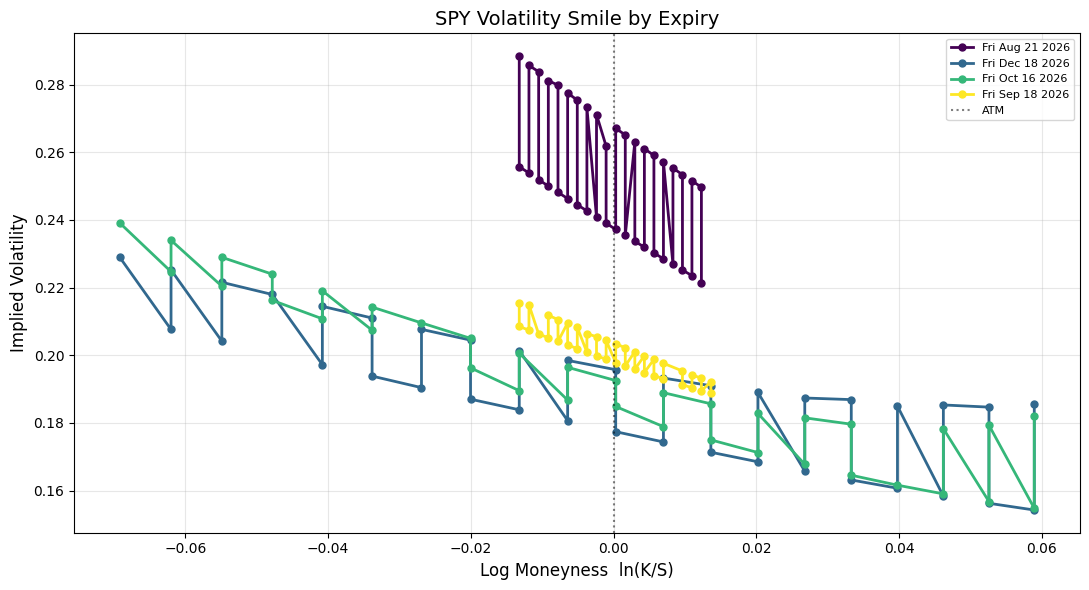

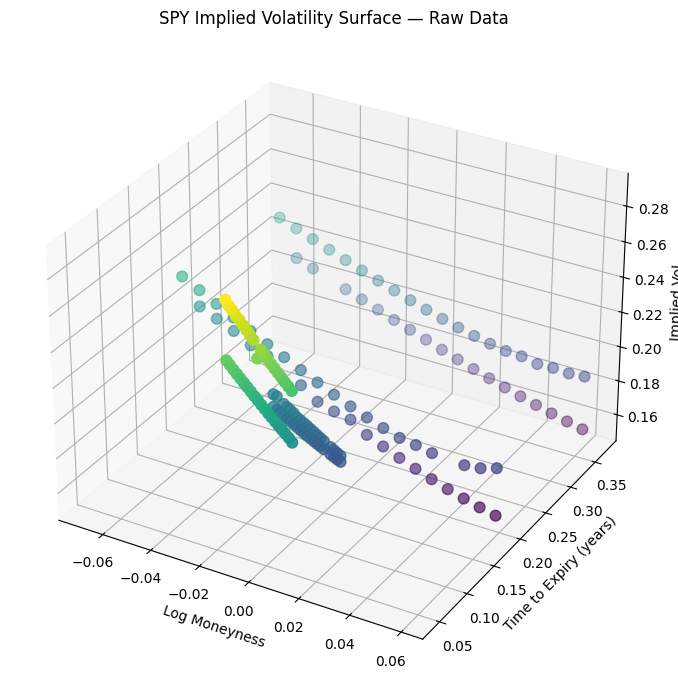

Fitting smoothing splines...
  T=0.044 yrs — smoothing spline on 20 points
  T=0.121 yrs — smoothing spline on 20 points
  T=0.197 yrs — smoothing spline on 20 points
  T=0.370 yrs — smoothing spline on 20 points


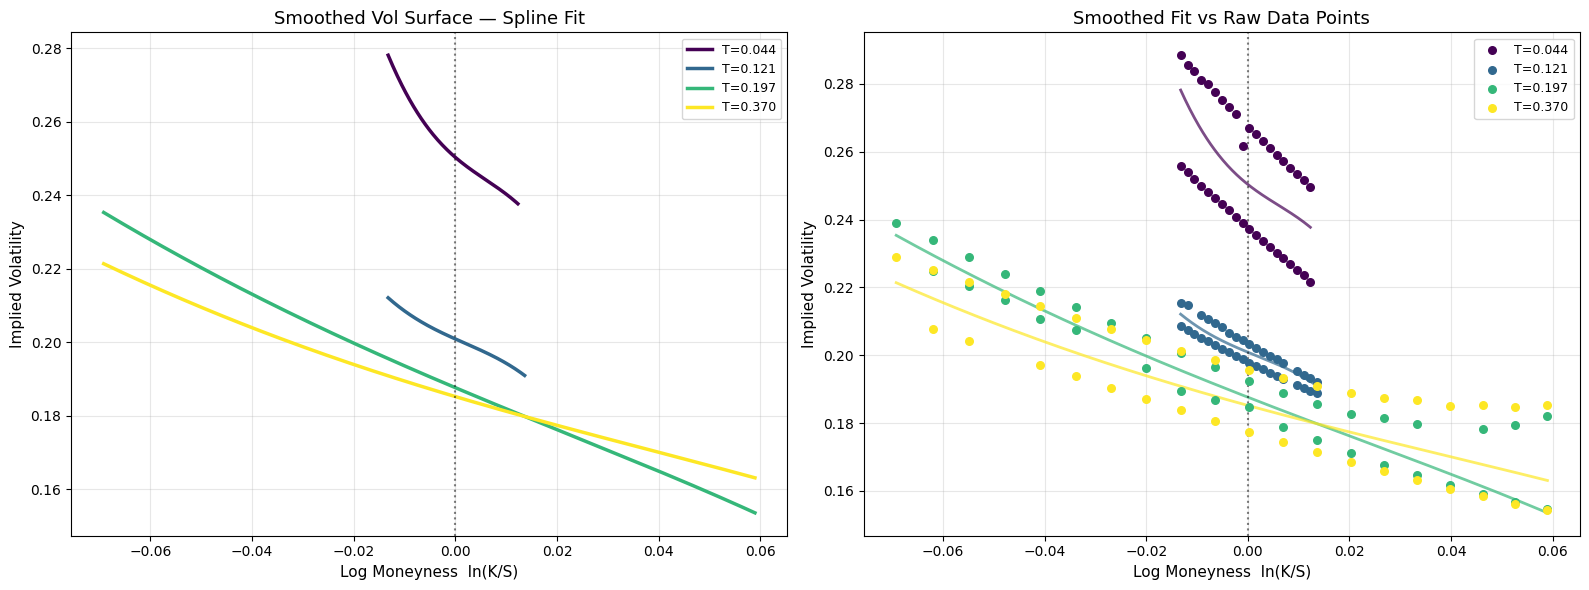

In [ ]:
# ============================================================
# WEEK 2 — FULL PIPELINE
# Cleaning, IV computation, surface construction, visualization
# ============================================================

from scipy.interpolate import CubicSpline
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ---- REDEFINE BSM FUNCTIONS (session-safe) ----

def bsm_call_price(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

def bsm_put_price(S, K, T, r, sigma):
    call = bsm_call_price(S, K, T, r, sigma)
    return call - S + K * np.exp(-r * T)

def vega(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return S * norm.pdf(d1) * np.sqrt(T)

def implied_vol(market_price, S, K, T, r, option_type='call',
                initial_guess=0.20, max_iterations=100, tolerance=1e-6):
    sigma = initial_guess
    for i in range(max_iterations):
        price = bsm_call_price(S, K, T, r, sigma) if option_type == 'call' \
                else bsm_put_price(S, K, T, r, sigma)
        diff = price - market_price
        if abs(diff) < tolerance:
            return sigma
        v = vega(S, K, T, r, sigma)
        if v < 1e-8 or sigma <= 0 or sigma > 5:
            break
        sigma = sigma - diff / v
    try:
        objective = lambda s: (bsm_call_price(S, K, T, r, s) if option_type == 'call'
                               else bsm_put_price(S, K, T, r, s)) - market_price
        return brentq(objective, 1e-6, 5.0, xtol=tolerance)
    except:
        return np.nan

# ---- MARKET INPUTS ----

S = 744.78
r = 0.053
today = datetime.today()

# ---- SELECT ONE EXPIRY PER MONTH FOR A CLEAN SURFACE ----
# We pick the standard monthly expiry (third Friday of each month)
# plus one near-term weekly for the short end

target_expiries = [
    'Thu Jul 02 2026',   # very short dated — shows steep smile
    'Fri Jul 17 2026',   # ~2 weeks
    'Fri Aug 21 2026',   # ~7 weeks — standard monthly
    'Fri Sep 18 2026',   # ~11 weeks — standard monthly
    'Fri Oct 16 2026',   # ~15 weeks — standard monthly
    'Fri Dec 18 2026',   # ~24 weeks — standard monthly
]

df_filtered = df_raw[df_raw['Expiration Date'].isin(target_expiries)].copy()
print(f"Rows after expiry filter: {len(df_filtered)}")
print(df_filtered['Expiration Date'].value_counts().sort_index())

# ---- COMPUTE T ----

df_filtered['Expiry_dt'] = pd.to_datetime(df_filtered['Expiration Date'])
df_filtered['T'] = (df_filtered['Expiry_dt'] - today).dt.days / 365

# ---- SPLIT CALLS AND PUTS ----

calls = df_filtered[[
    'Expiration Date', 'Expiry_dt', 'T', 'Strike',
    'Calls', 'Last Sale', 'Net', 'Bid', 'Ask', 'Volume',
    'IV', 'Delta', 'Gamma', 'Open Interest'
]].copy()
calls.columns = [
    'Expiration Date', 'Expiry_dt', 'T', 'Strike',
    'Contract', 'Last Sale', 'Net', 'Bid', 'Ask', 'Volume',
    'IV_cboe', 'Delta_cboe', 'Gamma_cboe', 'Open Interest'
]
calls['option_type'] = 'call'

puts = df_filtered[[
    'Expiration Date', 'Expiry_dt', 'T', 'Strike',
    'Puts', 'Last Sale.1', 'Net.1', 'Bid.1', 'Ask.1', 'Volume.1',
    'IV.1', 'Delta.1', 'Gamma.1', 'Open Interest.1'
]].copy()
puts.columns = [
    'Expiration Date', 'Expiry_dt', 'T', 'Strike',
    'Contract', 'Last Sale', 'Net', 'Bid', 'Ask', 'Volume',
    'IV_cboe', 'Delta_cboe', 'Gamma_cboe', 'Open Interest'
]
puts['option_type'] = 'put'

options = pd.concat([calls, puts], ignore_index=True)
print(f"\nTotal options before cleaning: {len(options)}")

# ---- DATA CLEANING ----

options['Mid'] = (options['Bid'] + options['Ask']) / 2
options['Moneyness'] = options['Strike'] / S

n = len(options)
options = options[options['Volume'] > 0]
print(f"After zero volume filter:       {len(options)} (removed {n - len(options)})")

n = len(options)
options = options[options['Open Interest'] > 10]
print(f"After low open interest filter: {len(options)} (removed {n - len(options)})")

n = len(options)
options = options[options['Bid'] > 0]
print(f"After zero bid filter:          {len(options)} (removed {n - len(options)})")

n = len(options)
options = options[options['T'] > 1/365]
print(f"After short dated filter:       {len(options)} (removed {n - len(options)})")

n = len(options)
options = options[(options['Moneyness'] >= 0.85) & (options['Moneyness'] <= 1.15)]
print(f"After deep ITM/OTM filter:      {len(options)} (removed {n - len(options)})")

options = options.reset_index(drop=True)
print(f"\nFinal clean dataset: {len(options)} options")

# ---- COMPUTE IMPLIED VOL ----

def compute_iv_row(row):
    try:
        return implied_vol(row['Mid'], S, row['Strike'],
                          row['T'], r, row['option_type'])
    except:
        return np.nan

options['IV_computed'] = options.apply(compute_iv_row, axis=1)
options = options.dropna(subset=['IV_computed'])
options['log_moneyness'] = np.log(options['Strike'] / S)

print(f"IV computed for {len(options)} options")
print(f"\nOptions per expiry:")
print(options.groupby('Expiration Date')['IV_computed'].count())

# ---- PLOT 1: 2D SMILE SLICES ----

fig, ax = plt.subplots(figsize=(11, 6))

# Use one color per expiry, plot calls and puts together
expiry_list = options['Expiration Date'].unique()
colors = plt.cm.viridis(np.linspace(0, 1, len(expiry_list)))

for i, expiry in enumerate(sorted(expiry_list)):
    slice_data = options[options['Expiration Date'] == expiry].sort_values('log_moneyness')
    ax.plot(slice_data['log_moneyness'], slice_data['IV_computed'],
            'o-', color=colors[i], label=expiry, linewidth=2, markersize=5)

ax.axvline(x=0, color='black', linestyle=':', alpha=0.5, label='ATM')
ax.set_xlabel('Log Moneyness  ln(K/S)', fontsize=12)
ax.set_ylabel('Implied Volatility', fontsize=12)
ax.set_title('SPY Volatility Smile by Expiry', fontsize=14)
ax.legend(fontsize=8, loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ---- PLOT 2: 3D SURFACE ----

fig = plt.figure(figsize=(12, 7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(options['log_moneyness'], options['T'], options['IV_computed'],
           c=options['IV_computed'], cmap='viridis', s=60)

ax.set_xlabel('Log Moneyness')
ax.set_ylabel('Time to Expiry (years)')
ax.set_zlabel('Implied Vol')
ax.set_title('SPY Implied Volatility Surface — Raw Data')
plt.tight_layout()
plt.show()

from scipy.interpolate import UnivariateSpline

# ---- SMOOTHING SPLINE INTERPOLATION ----
# UnivariateSpline with smoothing factor s > 0 fits a smooth curve
# near the data rather than exactly through it — much better for
# noisy financial data with tightly packed strikes

print("Fitting smoothing splines...")
smooth_splines = {}

for expiry_T, group in options.groupby('T'):
    slice_data = group.sort_values('log_moneyness').drop_duplicates('log_moneyness')
    k_vals  = slice_data['log_moneyness'].values
    # Interpolate in total variance space
    w_vals  = (slice_data['IV_computed'].values ** 2) * expiry_T

    if len(k_vals) >= 4:
        # Apply more smoothing for wider strike ranges (longer dated expiries)
        # The wider the strike range, the more the spline needs to be constrained
        k_range = k_vals.max() - k_vals.min()
        if k_range > 0.05:
            s = len(k_vals) * (0.008 ** 2)  # heavy smoothing for wide range
        elif k_range > 0.02:
            s = len(k_vals) * (0.004 ** 2)  # medium smoothing
        else:
            s = len(k_vals) * (0.002 ** 2)  # light smoothing for narrow range
        try:
            spline = UnivariateSpline(k_vals, w_vals, s=s, k=3)
            smooth_splines[expiry_T] = {
                'spline': spline,
                'k_min': k_vals.min(),
                'k_max': k_vals.max()
            }
            print(f"  T={expiry_T:.3f} yrs — smoothing spline on {len(k_vals)} points")
        except Exception as e:
            print(f"  T={expiry_T:.3f} yrs — failed: {e}")

# ---- PLOT SMOOTHED SURFACE ----

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

expiry_ts_sorted = sorted(smooth_splines.keys())
colors = plt.cm.viridis(np.linspace(0, 1, len(expiry_ts_sorted)))

# Left plot: smoothed spline curves
ax = axes[0]
for i, T in enumerate(expiry_ts_sorted):
    kmin = smooth_splines[T]['k_min']
    kmax = smooth_splines[T]['k_max']
    k_plot = np.linspace(kmin, kmax, 200)

    w_plot = smooth_splines[T]['spline'](k_plot)
    # Convert total variance back to IV
    iv_plot = np.sqrt(np.maximum(w_plot, 1e-8) / T)

    ax.plot(k_plot, iv_plot, '-', color=colors[i],
            label=f'T={T:.3f}', linewidth=2.5)

ax.axvline(x=0, color='black', linestyle=':', alpha=0.5)
ax.set_xlabel('Log Moneyness  ln(K/S)', fontsize=11)
ax.set_ylabel('Implied Volatility', fontsize=11)
ax.set_title('Smoothed Vol Surface — Spline Fit', fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Right plot: raw data points overlaid for comparison
ax2 = axes[1]
for i, T in enumerate(expiry_ts_sorted):
    slice_data = options[options['T'].round(3) == round(T, 3)].sort_values('log_moneyness')
    ax2.scatter(slice_data['log_moneyness'], slice_data['IV_computed'],
                color=colors[i], s=30, label=f'T={T:.3f}', zorder=5)

    # Overlay the smooth fit
    kmin = smooth_splines[T]['k_min']
    kmax = smooth_splines[T]['k_max']
    k_plot = np.linspace(kmin, kmax, 200)
    w_plot = smooth_splines[T]['spline'](k_plot)
    iv_plot = np.sqrt(np.maximum(w_plot, 1e-8) / T)
    ax2.plot(k_plot, iv_plot, '-', color=colors[i], linewidth=2, alpha=0.7)

ax2.axvline(x=0, color='black', linestyle=':', alpha=0.5)
ax2.set_xlabel('Log Moneyness  ln(K/S)', fontsize=11)
ax2.set_ylabel('Implied Volatility', fontsize=11)
ax2.set_title('Smoothed Fit vs Raw Data Points', fontsize=13)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ---- UPDATE VOL SURFACE CLASS TO USE SMOOTHING SPLINES ----

class VolSurface:
    def __init__(self, smooth_splines_dict, S):
        self.S = S
        self.smooth_splines = smooth_splines_dict
        self.expiry_ts = sorted(smooth_splines_dict.keys())

    def _query(self, T, k):
        k_min = self.smooth_splines[T]['k_min']
        k_max = self.smooth_splines[T]['k_max']
        k_clamped = np.clip(k, k_min, k_max)
        w = self.smooth_splines[T]['spline'](k_clamped)
        return max(float(w), 1e-8)

    def get_iv(self, K, T):
        k = np.log(K / self.S)
        ts = self.expiry_ts

        if T <= ts[0]:
            w = self._query(ts[0], k)

Saving spy_quotedata august.csv to spy_quotedata august (2).csv
Saving spy_quotedata december.csv to spy_quotedata december (2).csv
Saving spy_quotedata july.csv to spy_quotedata july (2).csv
Saving spy_quotedata october.csv to spy_quotedata october (2).csv
Saving spy_quotedata september.csv to spy_quotedata september (2).csv
Options loaded: 154 across 4 expiries
Matched call-put pairs: 74

Dividend-Adjusted Put-Call Parity Violation Summary:
  Total pairs tested:          74
  Violations found (raw):      74
  Violations > $0.10:          72
  Tradeable after costs:       48

  Mean raw violation:          $1.3853
  Max raw violation:           $2.3687
  Mean transaction cost:       $0.7325

Dividend-adjusted detailed results:
    Expiration Date  Strike     LHS  RHS_div_adjusted  PCP_violation_div  Transaction_cost  Net_violation_div  Tradeable_div
0   Fri Aug 21 2026   735.0  13.430         11.061333           2.368667             0.130           2.238667           True
1   Fri Aug 

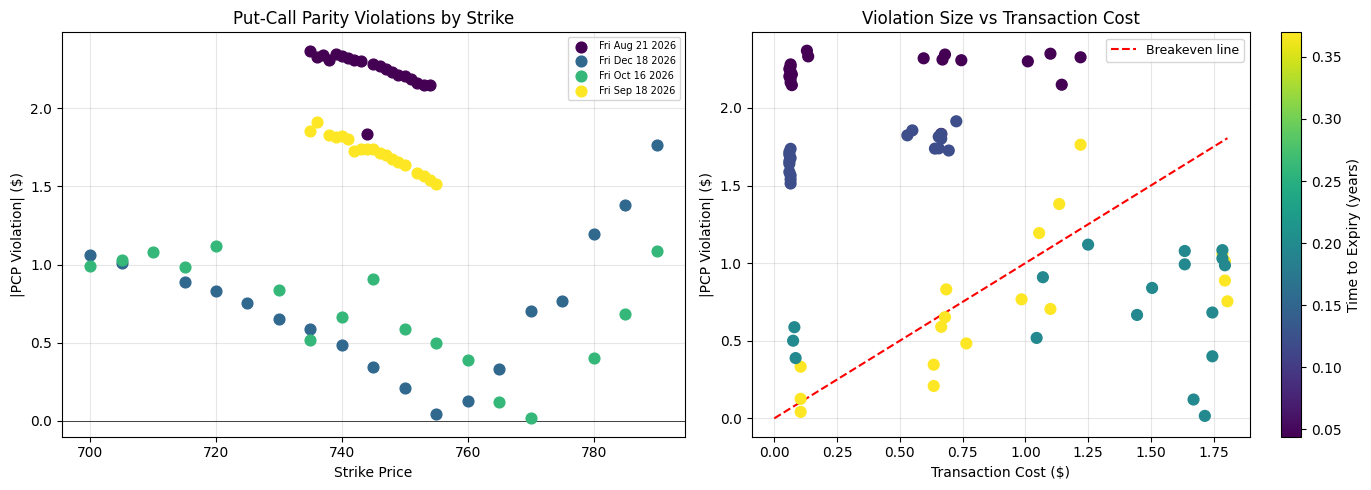

Implied dividend yield per expiry:
                   mean     std     min     max
Expiration Date                                
Fri Aug 21 2026 -0.0557  0.0036 -0.0595 -0.0431
Fri Dec 18 2026  0.0129  0.0032  0.0091  0.0194
Fri Oct 16 2026  0.0100  0.0045  0.0054  0.0204
Fri Sep 18 2026 -0.0061  0.0012 -0.0083 -0.0039

Our assumed q: 0.013 (1.3%)
Actual SPY dividend yield varies by expiry based on ex-div dates
Using these implied dividend yields:
Expiration Date
Fri Aug 21 2026   -0.0557
Fri Dec 18 2026    0.0129
Fri Oct 16 2026    0.0100
Fri Sep 18 2026   -0.0061
Name: implied_q, dtype: float64

Per-Expiry Dividend Adjusted Summary:
  Total pairs tested:      74
  Violations > $0.10:      43
  Tradeable after costs:   14
  Mean raw violation:      $0.3379
  Max raw violation:       $1.7956

Violations by expiry:
                 mean_violation  max_violation  tradeable  total
Expiration Date                                                 
Fri Aug 21 2026          0.0823         0.

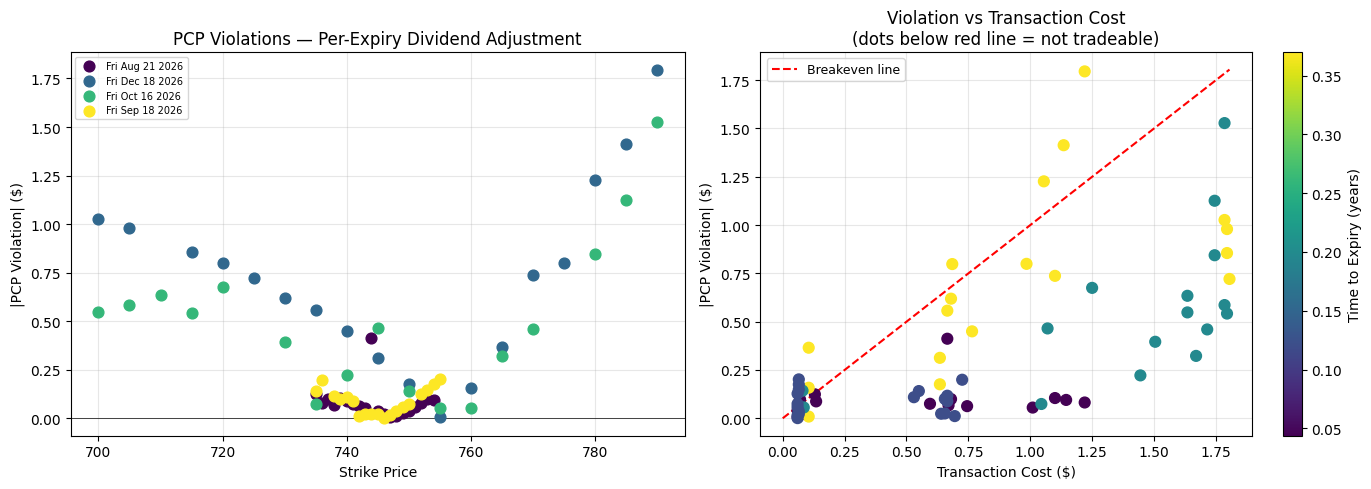


STEP 2: BUTTERFLY SPREAD CHECKS

Butterfly Spread Summary:
  Total triplets tested:       59
  Negative butterfly (raw):    10
  Tradeable after costs:       0

  Mean butterfly price:        $0.0828
  Min butterfly price:         $-0.4400
  Max butterfly price:         $0.9150

By expiry:
                 total  violations  tradeable  mean_price  min_price
Expiration Date                                                     
Fri Aug 21 2026     18           4          0      0.0119      -0.44
Fri Dec 18 2026     14           0          0      0.1286       0.07
Fri Oct 16 2026     14           2          0      0.1971      -0.38
Fri Sep 18 2026     13           4          0      0.0085      -0.05


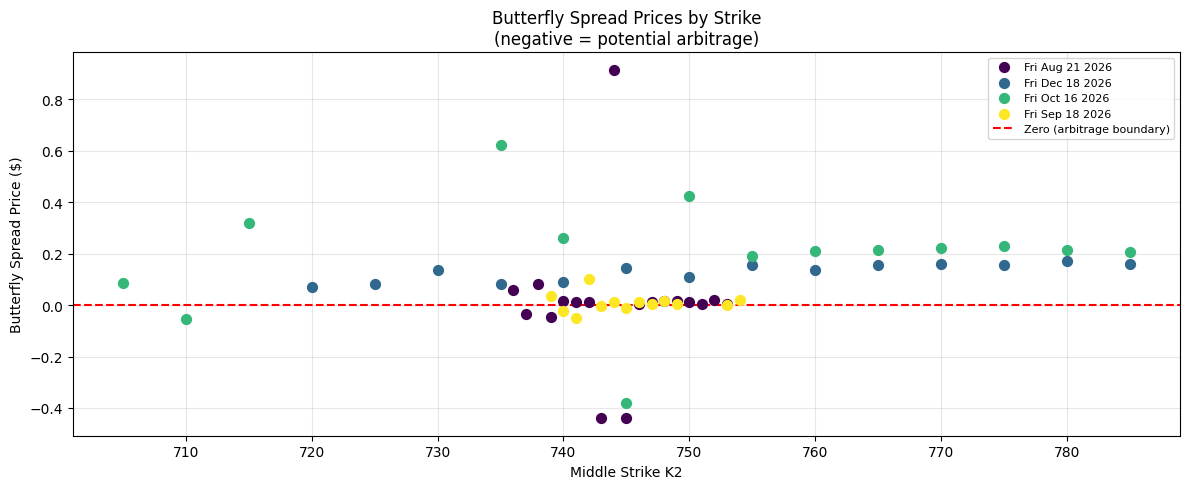


STEP 3: CALENDAR SPREAD CHECKS
Expiries in order: [('Fri Aug 21 2026', '0.044'), ('Fri Sep 18 2026', '0.121'), ('Fri Oct 16 2026', '0.197'), ('Fri Dec 18 2026', '0.370')]

Calendar Spread Summary:
  Strike pairs tested:         40
  Violations found:            0
  No violations found


By expiry pair:
                                 strikes_tested  violations  mean_tv_short  \
Expiry_short    Expiry_long                                                  
Fri Aug 21 2026 Fri Sep 18 2026              18           0       0.003150   
Fri Oct 16 2026 Fri Dec 18 2026              17           0       0.006697   
Fri Sep 18 2026 Fri Oct 16 2026               5           0       0.005008   

                                 mean_tv_long  
Expiry_short    Expiry_long                    
Fri Aug 21 2026 Fri Sep 18 2026      0.005024  
Fri Oct 16 2026 Fri Dec 18 2026      0.011653  
Fri Sep 18 2026 Fri Oct 16 2026      0.006613  


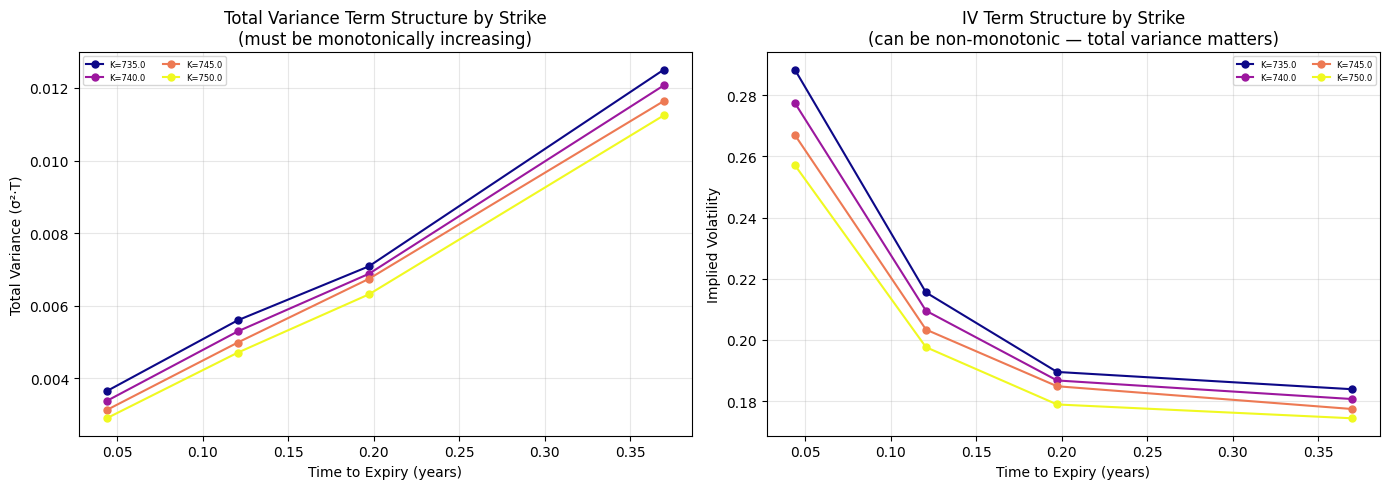


STEP 4: VARIANCE RISK PREMIUM


/tmp/ipykernel_400/2466553404.py:566: FutureWarning: YF.download() has changed argument auto_adjust default to True
  spy = yf.download('SPY', start='2024-01-01', end=today.strftime('%Y-%m-%d'),


Downloaded 648 trading days of SPY data

Current ATM Implied Vols by expiry:
  Fri Aug 21 2026: 0.2671 (26.71%)
  Fri Dec 18 2026: 0.1774 (17.74%)
  Fri Oct 16 2026: 0.1849 (18.49%)
  Fri Sep 18 2026: 0.2034 (20.34%)


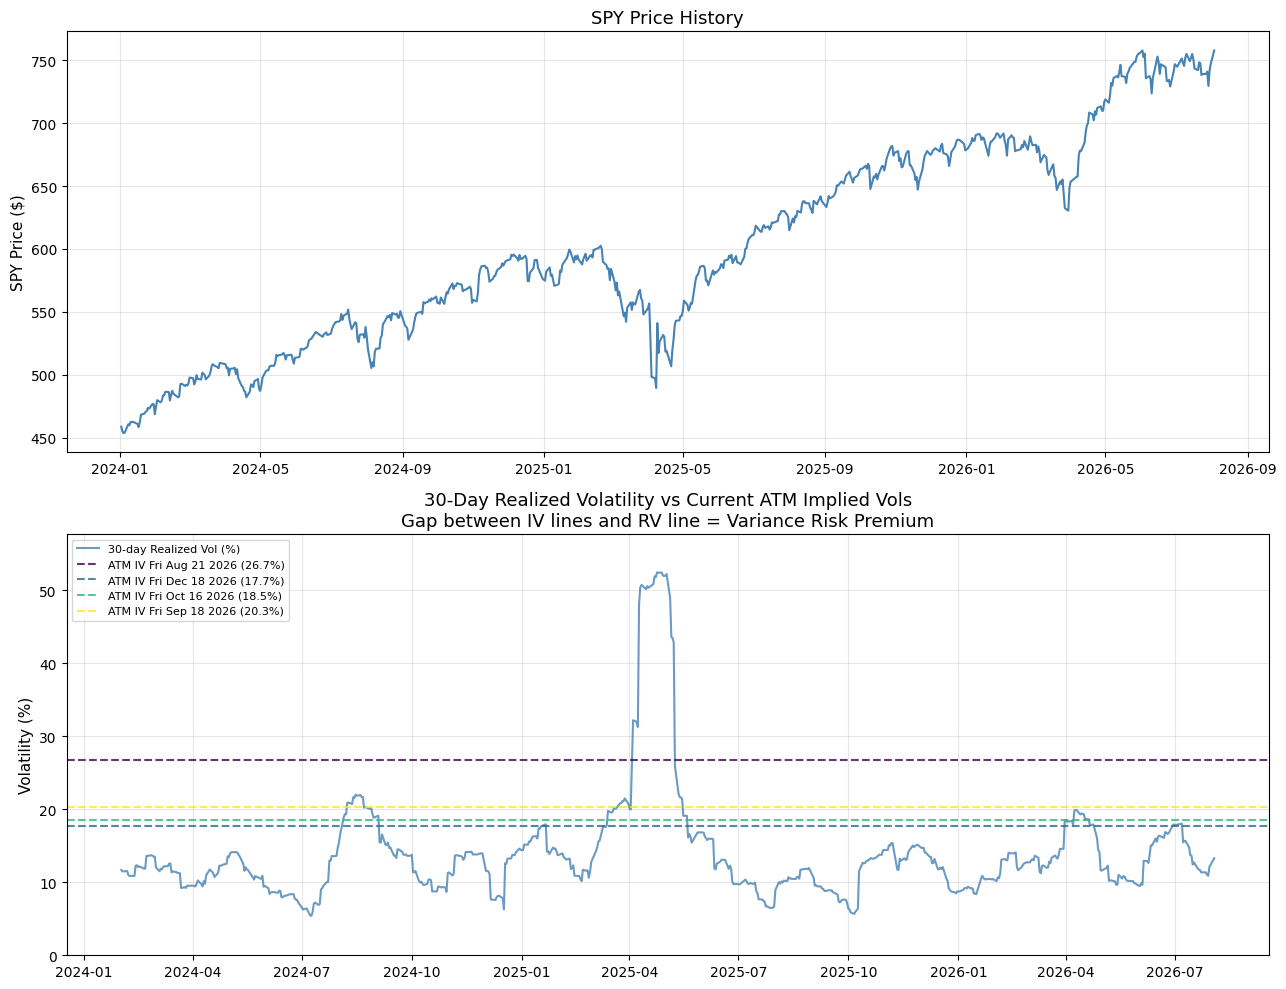


Realized Volatility:
  Most recent 30-day RV:  13.29%
  Mean RV (past 1 year):  12.35%
  Mean RV (full history): 14.00%

Variance Risk Premium (ATM IV minus recent RV):
  Fri Aug 21 2026: IV=26.71%  RV=13.29%  VRP=13.42% (positive)
  Fri Dec 18 2026: IV=17.74%  RV=13.29%  VRP=4.45% (positive)
  Fri Oct 16 2026: IV=18.49%  RV=13.29%  VRP=5.20% (positive)
  Fri Sep 18 2026: IV=20.34%  RV=13.29%  VRP=7.05% (positive)

Variance Risk Premium (ATM IV minus 1-year mean RV):
  Fri Aug 21 2026: VRP=14.36% (positive)
  Fri Dec 18 2026: VRP=5.39% (positive)
  Fri Oct 16 2026: VRP=6.14% (positive)
  Fri Sep 18 2026: VRP=7.99% (positive)

VRP Summary Table:
Expiry                 ATM IV   vs Recent RV   vs 1yr Mean RV Interpretation
---------------------------------------------------------------------------
Fri Dec 18 2026        17.74%     +4.45pp       +5.39pp   Event premium priced in
Fri Oct 16 2026        18.49%     +5.20pp       +6.14pp   Event premium priced in
Fri Sep 18 2026        20.34%

In [ ]:
# ============================================================
# WEEKS 3 AND 4 — ARBITRAGE DETECTION
# Fully self-contained — rebuilds options DataFrame from scratch
# ============================================================

from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import io
from datetime import datetime
from scipy.stats import norm
from scipy.optimize import brentq
from scipy.interpolate import UnivariateSpline

# ---- BSM FUNCTIONS ----

def bsm_call_price(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

def bsm_put_price(S, K, T, r, sigma):
    call = bsm_call_price(S, K, T, r, sigma)
    return call - S + K * np.exp(-r * T)

def vega(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return S * norm.pdf(d1) * np.sqrt(T)

def implied_vol(market_price, S, K, T, r, option_type='call',
                initial_guess=0.20, max_iterations=100, tolerance=1e-6):
    sigma = initial_guess
    for i in range(max_iterations):
        price = bsm_call_price(S, K, T, r, sigma) if option_type == 'call' \
                else bsm_put_price(S, K, T, r, sigma)
        diff = price - market_price
        if abs(diff) < tolerance:
            return sigma
        v = vega(S, K, T, r, sigma)
        if v < 1e-8 or sigma <= 0 or sigma > 5:
            break
        sigma = sigma - diff / v
    try:
        objective = lambda s: (bsm_call_price(S, K, T, r, s) if option_type == 'call'
                               else bsm_put_price(S, K, T, r, s)) - market_price
        return brentq(objective, 1e-6, 5.0, xtol=tolerance)
    except:
        return np.nan

# ---- UPLOAD ALL 5 FILES ----

uploaded = files.upload()

S = 744.78
r = 0.053
today = datetime.today()

target_expiries = [
    'Thu Jul 02 2026',
    'Fri Jul 17 2026',
    'Fri Aug 21 2026',
    'Fri Sep 18 2026',
    'Fri Oct 16 2026',
    'Fri Dec 18 2026',
]

# ---- LOAD AND COMBINE ----

all_dfs = []
for filename, content in uploaded.items():
    text = content.decode('utf-8')
    df = pd.read_csv(io.StringIO(text), skiprows=3)
    df['source_file'] = filename
    all_dfs.append(df)

df_raw = pd.concat(all_dfs, ignore_index=True)
df_filtered = df_raw[df_raw['Expiration Date'].isin(target_expiries)].copy()

# ---- COMPUTE T ----

df_filtered['Expiry_dt'] = pd.to_datetime(df_filtered['Expiration Date'])
df_filtered['T'] = (df_filtered['Expiry_dt'] - today).dt.days / 365

# ---- SPLIT CALLS AND PUTS ----

calls = df_filtered[[
    'Expiration Date', 'Expiry_dt', 'T', 'Strike',
    'Calls', 'Last Sale', 'Net', 'Bid', 'Ask', 'Volume',
    'IV', 'Delta', 'Gamma', 'Open Interest'
]].copy()
calls.columns = [
    'Expiration Date', 'Expiry_dt', 'T', 'Strike',
    'Contract', 'Last Sale', 'Net', 'Bid', 'Ask', 'Volume',
    'IV_cboe', 'Delta_cboe', 'Gamma_cboe', 'Open Interest'
]
calls['option_type'] = 'call'

puts = df_filtered[[
    'Expiration Date', 'Expiry_dt', 'T', 'Strike',
    'Puts', 'Last Sale.1', 'Net.1', 'Bid.1', 'Ask.1', 'Volume.1',
    'IV.1', 'Delta.1', 'Gamma.1', 'Open Interest.1'
]].copy()
puts.columns = [
    'Expiration Date', 'Expiry_dt', 'T', 'Strike',
    'Contract', 'Last Sale', 'Net', 'Bid', 'Ask', 'Volume',
    'IV_cboe', 'Delta_cboe', 'Gamma_cboe', 'Open Interest'
]
puts['option_type'] = 'put'

options = pd.concat([calls, puts], ignore_index=True)

# ---- CLEAN ----

options['Mid'] = (options['Bid'] + options['Ask']) / 2
options['Moneyness'] = options['Strike'] / S

options = options[options['Volume'] > 0]
options = options[options['Open Interest'] > 10]
options = options[options['Bid'] > 0]
options = options[options['T'] > 1/365]
options = options[(options['Moneyness'] >= 0.85) & (options['Moneyness'] <= 1.15)]
options = options.reset_index(drop=True)

# ---- COMPUTE IV ----

def compute_iv_row(row):
    try:
        return implied_vol(row['Mid'], S, row['Strike'],
                          row['T'], r, row['option_type'])
    except:
        return np.nan

options['IV_computed'] = options.apply(compute_iv_row, axis=1)
options = options.dropna(subset=['IV_computed'])
options['log_moneyness'] = np.log(options['Strike'] / S)

print(f"Options loaded: {len(options)} across {options['Expiration Date'].nunique()} expiries")

# ---- PUT-CALL PARITY CHECK ----

calls_pcp = options[options['option_type'] == 'call'][
    ['Expiration Date', 'T', 'Strike', 'Bid', 'Ask', 'Mid', 'IV_computed']
].copy()
calls_pcp.columns = [
    'Expiration Date', 'T', 'Strike',
    'Call_Bid', 'Call_Ask', 'Call_Mid', 'Call_IV'
]

puts_pcp = options[options['option_type'] == 'put'][
    ['Expiration Date', 'T', 'Strike', 'Bid', 'Ask', 'Mid', 'IV_computed']
].copy()
puts_pcp.columns = [
    'Expiration Date', 'T', 'Strike',
    'Put_Bid', 'Put_Ask', 'Put_Mid', 'Put_IV'
]

pcp = pd.merge(calls_pcp, puts_pcp, on=['Expiration Date', 'T', 'Strike'])
print(f"Matched call-put pairs: {len(pcp)}")

# Left side: C - P
pcp['LHS'] = pcp['Call_Mid'] - pcp['Put_Mid']

# Right side: S - K*e^(-rT)
pcp['RHS'] = S - pcp['Strike'] * np.exp(-r * pcp['T'])

# Raw violation
pcp['PCP_violation'] = pcp['LHS'] - pcp['RHS']
pcp['PCP_violation_abs'] = pcp['PCP_violation'].abs()

# Transaction cost estimate
pcp['Call_spread'] = pcp['Call_Ask'] - pcp['Call_Bid']
pcp['Put_spread']  = pcp['Put_Ask']  - pcp['Put_Bid']
pcp['Transaction_cost'] = 0.5 * pcp['Call_spread'] + 0.5 * pcp['Put_spread']

# Net violation after costs
pcp['Net_violation'] = pcp['PCP_violation_abs'] - pcp['Transaction_cost']
pcp['Tradeable'] = pcp['Net_violation'] > 0

q = 0.013  # SPY continuous dividend yield, approximately 1.2-1.3% annually

# Dividend-adjusted put-call parity:
# C - P = S*e^(-qT) - K*e^(-rT)
pcp['RHS_div_adjusted'] = S * np.exp(-q * pcp['T']) - pcp['Strike'] * np.exp(-r * pcp['T'])

# Recompute violations using dividend-adjusted RHS
pcp['PCP_violation_div'] = pcp['LHS'] - pcp['RHS_div_adjusted']
pcp['PCP_violation_div_abs'] = pcp['PCP_violation_div'].abs()

# Net violation after transaction costs
pcp['Net_violation_div'] = pcp['PCP_violation_div_abs'] - pcp['Transaction_cost']
pcp['Tradeable_div'] = pcp['Net_violation_div'] > 0

print(f"\nDividend-Adjusted Put-Call Parity Violation Summary:")
print(f"  Total pairs tested:          {len(pcp)}")
print(f"  Violations found (raw):      {(pcp['PCP_violation_div_abs'] > 0.01).sum()}")
print(f"  Violations > $0.10:          {(pcp['PCP_violation_div_abs'] > 0.10).sum()}")
print(f"  Tradeable after costs:       {pcp['Tradeable_div'].sum()}")
print(f"\n  Mean raw violation:          ${pcp['PCP_violation_div_abs'].mean():.4f}")
print(f"  Max raw violation:           ${pcp['PCP_violation_div_abs'].max():.4f}")
print(f"  Mean transaction cost:       ${pcp['Transaction_cost'].mean():.4f}")

print(f"\nDividend-adjusted detailed results:")
print(pcp[[
    'Expiration Date', 'Strike', 'LHS', 'RHS_div_adjusted',
    'PCP_violation_div', 'Transaction_cost', 'Net_violation_div', 'Tradeable_div'
]].to_string())


# ---- PLOT ----

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
colors = plt.cm.viridis(np.linspace(0, 1, pcp['Expiration Date'].nunique()))
for i, (expiry, group) in enumerate(pcp.groupby('Expiration Date')):
    ax.scatter(group['Strike'], group['PCP_violation_div_abs'],
           color=colors[i], label=expiry, s=60, zorder=5)
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.set_xlabel('Strike Price')
ax.set_ylabel('|PCP Violation| ($)')
ax.set_title('Put-Call Parity Violations by Strike')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

ax2 = axes[1]
scatter = ax2.scatter(pcp['Transaction_cost'], pcp['PCP_violation_div_abs'],
                      c=pcp['T'], cmap='viridis', s=60, zorder=5)
ax2.plot([0, pcp['Transaction_cost'].max()],
         [0, pcp['Transaction_cost'].max()],
         'r--', label='Breakeven line', linewidth=1.5)
ax2.set_xlabel('Transaction Cost ($)')
ax2.set_ylabel('|PCP Violation| ($)')
ax2.set_title('Violation Size vs Transaction Cost')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax2, label='Time to Expiry (years)')

plt.tight_layout()
plt.show()


# ---- DIAGNOSE REMAINING VIOLATIONS ----
# Find the implied dividend yield per expiry that zeros out violations
# C - P = S*e^(-qT) - K*e^(-rT)
# Solve for q: q = -ln((LHS + K*e^(-rT)) / S) / T

pcp['K_discounted'] = pcp['Strike'] * np.exp(-r * pcp['T'])
pcp['implied_q'] = -np.log((pcp['LHS'] + pcp['K_discounted']) / S) / pcp['T']

print("Implied dividend yield per expiry:")
print(pcp.groupby('Expiration Date')['implied_q'].agg(['mean', 'std', 'min', 'max']).round(4))

print(f"\nOur assumed q: 0.013 (1.3%)")
print(f"Actual SPY dividend yield varies by expiry based on ex-div dates")


# ---- USE IMPLIED DIVIDEND YIELDS PER EXPIRY ----
# These are derived directly from market prices via put-call parity
# Much more accurate than a flat q assumption

implied_q_per_expiry = pcp.groupby('Expiration Date')['implied_q'].mean()
print("Using these implied dividend yields:")
print(implied_q_per_expiry.round(4))

# Recompute violations using per-expiry implied q
def compute_rhs_per_expiry(row):
    q_expiry = implied_q_per_expiry[row['Expiration Date']]
    return S * np.exp(-q_expiry * row['T']) - row['Strike'] * np.exp(-r * row['T'])

pcp['RHS_per_expiry'] = pcp.apply(compute_rhs_per_expiry, axis=1)
pcp['PCP_violation_per_expiry'] = pcp['LHS'] - pcp['RHS_per_expiry']
pcp['PCP_violation_per_expiry_abs'] = pcp['PCP_violation_per_expiry'].abs()
pcp['Net_violation_per_expiry'] = pcp['PCP_violation_per_expiry_abs'] - pcp['Transaction_cost']
pcp['Tradeable_per_expiry'] = pcp['Net_violation_per_expiry'] > 0

print(f"\nPer-Expiry Dividend Adjusted Summary:")
print(f"  Total pairs tested:      {len(pcp)}")
print(f"  Violations > $0.10:      {(pcp['PCP_violation_per_expiry_abs'] > 0.10).sum()}")
print(f"  Tradeable after costs:   {pcp['Tradeable_per_expiry'].sum()}")
print(f"  Mean raw violation:      ${pcp['PCP_violation_per_expiry_abs'].mean():.4f}")
print(f"  Max raw violation:       ${pcp['PCP_violation_per_expiry_abs'].max():.4f}")

# Breakdown by expiry
print(f"\nViolations by expiry:")
summary = pcp.groupby('Expiration Date').agg(
    mean_violation = ('PCP_violation_per_expiry_abs', 'mean'),
    max_violation  = ('PCP_violation_per_expiry_abs', 'max'),
    tradeable      = ('Tradeable_per_expiry', 'sum'),
    total          = ('Tradeable_per_expiry', 'count')
).round(4)
print(summary)

# ---- FINAL PLOT ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: violations by strike, per expiry
ax = axes[0]
colors = plt.cm.viridis(np.linspace(0, 1, pcp['Expiration Date'].nunique()))
for i, (expiry, group) in enumerate(pcp.groupby('Expiration Date')):
    ax.scatter(group['Strike'], group['PCP_violation_per_expiry_abs'],
               color=colors[i], label=expiry, s=60, zorder=5)
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.set_xlabel('Strike Price')
ax.set_ylabel('|PCP Violation| ($)')
ax.set_title('PCP Violations — Per-Expiry Dividend Adjustment')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

# Right: violation vs transaction cost with breakeven line
ax2 = axes[1]
scatter = ax2.scatter(pcp['Transaction_cost'], pcp['PCP_violation_per_expiry_abs'],
                      c=pcp['T'], cmap='viridis', s=60, zorder=5)
max_val = max(pcp['Transaction_cost'].max(), pcp['PCP_violation_per_expiry_abs'].max())
ax2.plot([0, max_val], [0, max_val], 'r--', label='Breakeven line', linewidth=1.5)
ax2.set_xlabel('Transaction Cost ($)')
ax2.set_ylabel('|PCP Violation| ($)')
ax2.set_title('Violation vs Transaction Cost\n(dots below red line = not tradeable)')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax2, label='Time to Expiry (years)')

plt.tight_layout()
plt.show()


# ============================================================
# STEP 2: BUTTERFLY SPREAD ARBITRAGE CHECK
# ============================================================
# For three strikes K1 < K2 < K3, a butterfly spread is:
# B = C(K1) - 2*C(K2) + C(K3)
# This must be >= 0. If negative, the surface is locally non-convex
# which implies negative probability density — impossible.

print("\n" + "="*60)
print("STEP 2: BUTTERFLY SPREAD CHECKS")
print("="*60)

# Work with calls only for butterfly checks — standard convention
calls_butterfly = options[options['option_type'] == 'call'].copy()
calls_butterfly = calls_butterfly.sort_values(['Expiration Date', 'Strike'])

butterfly_results = []

for expiry, group in calls_butterfly.groupby('Expiration Date'):
    strikes = sorted(group['Strike'].values)
    mids = dict(zip(group['Strike'], group['Mid']))
    T = group['T'].iloc[0]

    # Check every consecutive triplet of strikes
    for i in range(len(strikes) - 2):
        K1, K2, K3 = strikes[i], strikes[i+1], strikes[i+2]

        # Only check evenly spaced strikes for cleaner interpretation
        if abs((K3 - K2) - (K2 - K1)) > 0.01:
            continue

        C1 = mids[K1]
        C2 = mids[K2]
        C3 = mids[K3]

        # Butterfly price
        butterfly_price = C1 - 2*C2 + C3

        # Transaction cost: half spread on each of 4 legs
        # (buy K1, sell 2x K2, buy K3)
        spread_K1 = group[group['Strike']==K1]['Ask'].values[0] - \
                    group[group['Strike']==K1]['Bid'].values[0]
        spread_K2 = group[group['Strike']==K2]['Ask'].values[0] - \
                    group[group['Strike']==K2]['Bid'].values[0]
        spread_K3 = group[group['Strike']==K3]['Ask'].values[0] - \
                    group[group['Strike']==K3]['Bid'].values[0]

        # 4 legs total: 0.5 spread each
        transaction_cost = 0.5 * (spread_K1 + 2*spread_K2 + spread_K3)

        butterfly_results.append({
            'Expiration Date': expiry,
            'T': T,
            'K1': K1, 'K2': K2, 'K3': K3,
            'C1': C1, 'C2': C2, 'C3': C3,
            'Butterfly_price': butterfly_price,
            'Transaction_cost': transaction_cost,
            'Violation': butterfly_price < 0,
            'Tradeable': butterfly_price < -transaction_cost
        })

bf = pd.DataFrame(butterfly_results)

print(f"\nButterfly Spread Summary:")
print(f"  Total triplets tested:       {len(bf)}")
print(f"  Negative butterfly (raw):    {bf['Violation'].sum()}")
print(f"  Tradeable after costs:       {bf['Tradeable'].sum()}")
print(f"\n  Mean butterfly price:        ${bf['Butterfly_price'].mean():.4f}")
print(f"  Min butterfly price:         ${bf['Butterfly_price'].min():.4f}")
print(f"  Max butterfly price:         ${bf['Butterfly_price'].max():.4f}")

print(f"\nBy expiry:")
print(bf.groupby('Expiration Date').agg(
    total        = ('Butterfly_price', 'count'),
    violations   = ('Violation', 'sum'),
    tradeable    = ('Tradeable', 'sum'),
    mean_price   = ('Butterfly_price', 'mean'),
    min_price    = ('Butterfly_price', 'min')
).round(4))

# ---- PLOT ----
fig, ax = plt.subplots(figsize=(12, 5))

colors = plt.cm.viridis(np.linspace(0, 1, bf['Expiration Date'].nunique()))
for i, (expiry, group) in enumerate(bf.groupby('Expiration Date')):
    ax.scatter(group['K2'], group['Butterfly_price'],
               color=colors[i], label=expiry, s=50, zorder=5)

ax.axhline(y=0, color='red', linestyle='--', linewidth=1.5,
           label='Zero (arbitrage boundary)')
ax.set_xlabel('Middle Strike K2')
ax.set_ylabel('Butterfly Spread Price ($)')
ax.set_title('Butterfly Spread Prices by Strike\n(negative = potential arbitrage)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# STEP 3: CALENDAR SPREAD ARBITRAGE CHECK
# ============================================================
# For any fixed strike, total variance w = sigma^2 * T must be
# monotonically increasing as T increases.
# A calendar spread violation means a longer dated option has
# LESS total variance than a shorter dated one — impossible.

print("\n" + "="*60)
print("STEP 3: CALENDAR SPREAD CHECKS")
print("="*60)

# Use calls only, compute total variance at each (strike, expiry)
calls_cal = options[options['option_type'] == 'call'].copy()
calls_cal['total_variance'] = calls_cal['IV_computed']**2 * calls_cal['T']

# Get sorted list of expiries by T
expiry_order = calls_cal.groupby('Expiration Date')['T'].mean().sort_values()
expiry_dates = expiry_order.index.tolist()
expiry_Ts    = expiry_order.values.tolist()

print(f"Expiries in order: {list(zip(expiry_dates, [f'{t:.3f}' for t in expiry_Ts]))}")

calendar_results = []

# For each pair of consecutive expiries
for i in range(len(expiry_dates) - 1):
    exp1, exp2 = expiry_dates[i], expiry_dates[i+1]
    T1,   T2   = expiry_Ts[i],   expiry_Ts[i+1]

    slice1 = calls_cal[calls_cal['Expiration Date'] == exp1].set_index('Strike')
    slice2 = calls_cal[calls_cal['Expiration Date'] == exp2].set_index('Strike')

    # Only check strikes that appear in both expiries
    common_strikes = slice1.index.intersection(slice2.index)

    for K in common_strikes:
        w1 = slice1.loc[K, 'total_variance']
        w2 = slice2.loc[K, 'total_variance']

        violation = w2 < w1  # longer dated should have MORE total variance
        magnitude = w1 - w2  # how much it's violated (positive = violation)

        calendar_results.append({
            'Strike': K,
            'Expiry_short': exp1,
            'Expiry_long':  exp2,
            'T_short': T1,
            'T_long':  T2,
            'TotalVar_short': w1,
            'TotalVar_long':  w2,
            'Violation': violation,
            'Magnitude': magnitude if violation else 0
        })

cal = pd.DataFrame(calendar_results)

print(f"\nCalendar Spread Summary:")
print(f"  Strike pairs tested:         {len(cal)}")
print(f"  Violations found:            {cal['Violation'].sum()}")
print(f"  Mean violation magnitude:    {cal[cal['Violation']]['Magnitude'].mean():.6f}"
      if cal['Violation'].sum() > 0 else "  No violations found")
print(f"  Max violation magnitude:     {cal[cal['Violation']]['Magnitude'].max():.6f}"
      if cal['Violation'].sum() > 0 else "")

print(f"\nBy expiry pair:")
print(cal.groupby(['Expiry_short', 'Expiry_long']).agg(
    strikes_tested = ('Strike', 'count'),
    violations     = ('Violation', 'sum'),
    mean_tv_short  = ('TotalVar_short', 'mean'),
    mean_tv_long   = ('TotalVar_long', 'mean')
).round(6))

# ---- PLOT: Total variance term structure per strike ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: total variance vs T for each strike
ax = axes[0]
common_all = None
for exp in expiry_dates:
    s = set(calls_cal[calls_cal['Expiration Date']==exp]['Strike'].values)
    common_all = s if common_all is None else common_all & s

common_strikes_all = sorted(common_all)
colors_strikes = plt.cm.plasma(np.linspace(0, 1, len(common_strikes_all)))

for i, K in enumerate(common_strikes_all):
    tv_vals, t_vals = [], []
    for exp, T in zip(expiry_dates, expiry_Ts):
        row = calls_cal[(calls_cal['Expiration Date']==exp) &
                        (calls_cal['Strike']==K)]
        if len(row) > 0:
            tv_vals.append(row['total_variance'].values[0])
            t_vals.append(T)
    ax.plot(t_vals, tv_vals, 'o-', color=colors_strikes[i],
            label=f'K={K}', linewidth=1.5, markersize=5)

ax.set_xlabel('Time to Expiry (years)')
ax.set_ylabel('Total Variance (σ²·T)')
ax.set_title('Total Variance Term Structure by Strike\n(must be monotonically increasing)')
ax.legend(fontsize=6, ncol=2)
ax.grid(True, alpha=0.3)

# Right: IV term structure per strike (for comparison)
ax2 = axes[1]
for i, K in enumerate(common_strikes_all):
    iv_vals, t_vals = [], []
    for exp, T in zip(expiry_dates, expiry_Ts):
        row = calls_cal[(calls_cal['Expiration Date']==exp) &
                        (calls_cal['Strike']==K)]
        if len(row) > 0:
            iv_vals.append(row['IV_computed'].values[0])
            t_vals.append(T)
    ax2.plot(t_vals, iv_vals, 'o-', color=colors_strikes[i],
             label=f'K={K}', linewidth=1.5, markersize=5)

ax2.set_xlabel('Time to Expiry (years)')
ax2.set_ylabel('Implied Volatility')
ax2.set_title('IV Term Structure by Strike\n(can be non-monotonic — total variance matters)')
ax2.legend(fontsize=6, ncol=2)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# STEP 4: VARIANCE RISK PREMIUM ANALYSIS
# ============================================================
# The VRP is the spread between implied volatility (what the
# market prices in) and realized volatility (what actually happened).
# Historically IV > RV — options are on average overpriced.
# This persistent spread is the variance risk premium.

print("\n" + "="*60)
print("STEP 4: VARIANCE RISK PREMIUM")
print("="*60)

import yfinance as yf

# ---- PULL SPY HISTORICAL PRICE DATA ----
print("Downloading SPY historical data...")
spy = yf.download('SPY', start='2024-01-01', end=today.strftime('%Y-%m-%d'),
                  progress=False)

# Handle MultiIndex columns from yfinance
if isinstance(spy.columns, pd.MultiIndex):
    spy.columns = spy.columns.droplevel(1)

spy = spy[['Close']].copy()
spy.index = pd.to_datetime(spy.index)
print(f"Downloaded {len(spy)} trading days of SPY data")

# ---- COMPUTE 30-DAY ROLLING REALIZED VOLATILITY ----
# Daily log returns
spy['log_return'] = np.log(spy['Close'] / spy['Close'].shift(1))

# 30-day rolling realized vol, annualized
# Using 21 trading days as proxy for 30 calendar days
spy['RV_30d'] = spy['log_return'].rolling(21).std() * np.sqrt(252)

# ---- GET ATM IMPLIED VOL TIME SERIES ----
# We only have one snapshot of IV (today's data)
# So we'll show the current ATM IV as a reference line
# In a full project you'd want historical IV data

# Get ATM IV from our surface for each expiry
atm_ivs = {}
for expiry, group in options[options['option_type']=='call'].groupby('Expiration Date'):
    # Find the strike closest to ATM
    group['dist_from_atm'] = (group['Strike'] - S).abs()
    atm_row = group.loc[group['dist_from_atm'].idxmin()]
    atm_ivs[expiry] = atm_row['IV_computed']

print(f"\nCurrent ATM Implied Vols by expiry:")
for exp, iv in atm_ivs.items():
    print(f"  {exp}: {iv:.4f} ({iv*100:.2f}%)")

# ---- PLOT ----
fig, axes = plt.subplots(2, 1, figsize=(13, 10))

# Top plot: SPY price history
ax1 = axes[0]
ax1.plot(spy.index, spy['Close'], color='steelblue', linewidth=1.5)
ax1.set_ylabel('SPY Price ($)', fontsize=11)
ax1.set_title('SPY Price History', fontsize=13)
ax1.grid(True, alpha=0.3)

# Bottom plot: Realized vol vs current ATM implied vols
ax2 = axes[1]
ax2.plot(spy.index, spy['RV_30d'] * 100, color='steelblue',
         linewidth=1.5, label='30-day Realized Vol (%)', alpha=0.8)

# Add horizontal lines for current ATM IV at each expiry
colors_exp = plt.cm.viridis(np.linspace(0, 1, len(atm_ivs)))
for i, (exp, iv) in enumerate(atm_ivs.items()):
    ax2.axhline(y=iv*100, color=colors_exp[i], linestyle='--',
                linewidth=1.5, label=f'ATM IV {exp} ({iv*100:.1f}%)', alpha=0.8)

ax2.set_ylabel('Volatility (%)', fontsize=11)
ax2.set_title('30-Day Realized Volatility vs Current ATM Implied Vols\n'
              'Gap between IV lines and RV line = Variance Risk Premium',
              fontsize=13)
ax2.legend(fontsize=8, loc='upper left')
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, max(spy['RV_30d'].max()*110, max(atm_ivs.values())*110))

plt.tight_layout()
plt.show()

# ---- COMPUTE VRP STATISTICS ----
# Compare current ATM IVs to recent realized vol
recent_rv = spy['RV_30d'].dropna().iloc[-1]
mean_rv_1yr = spy['RV_30d'].dropna().iloc[-252:].mean()
mean_rv_full = spy['RV_30d'].dropna().mean()

print(f"\nRealized Volatility:")
print(f"  Most recent 30-day RV:  {recent_rv*100:.2f}%")
print(f"  Mean RV (past 1 year):  {mean_rv_1yr*100:.2f}%")
print(f"  Mean RV (full history): {mean_rv_full*100:.2f}%")

print(f"\nVariance Risk Premium (ATM IV minus recent RV):")
for exp, iv in atm_ivs.items():
    vrp = iv - recent_rv
    print(f"  {exp}: IV={iv*100:.2f}%  RV={recent_rv*100:.2f}%  "
          f"VRP={vrp*100:.2f}% ({'positive' if vrp > 0 else 'negative'})")

print(f"\nVariance Risk Premium (ATM IV minus 1-year mean RV):")
for exp, iv in atm_ivs.items():
    vrp = iv - mean_rv_1yr
    print(f"  {exp}: VRP={vrp*100:.2f}% ({'positive' if vrp > 0 else 'negative'})")


# ---- VRP SUMMARY TABLE ----
print("\nVRP Summary Table:")
print(f"{'Expiry':<20} {'ATM IV':>8} {'vs Recent RV':>14} {'vs 1yr Mean RV':>16} {'Interpretation'}")
print("-" * 75)

for exp, iv in sorted(atm_ivs.items(), key=lambda x: x[1]):
    vrp_recent = (iv - recent_rv) * 100
    vrp_1yr    = (iv - mean_rv_1yr) * 100

    if abs(vrp_recent) < 0.5:
        interp = "Fairly priced vs recent vol"
    elif vrp_recent > 2:
        interp = "Event premium priced in"
    elif vrp_recent < -1:
        interp = "IV below recent RV — unusual"
    else:
        interp = "Slight compression"

    print(f"{exp:<20} {iv*100:>7.2f}%  {vrp_recent:>+8.2f}pp  {vrp_1yr:>+10.2f}pp   {interp}")

print(f"\nNote: Recent RV={recent_rv*100:.2f}%  |  1yr Mean RV={mean_rv_1yr*100:.2f}%  |  Full hist RV={mean_rv_full*100:.2f}%")
print(f"\nKey insight: VRP compression vs recent RV reflects elevated realized vol")
print(f"in recent weeks. Against the 1-year mean, the VRP remains clearly positive")
print(f"at 2.9-7.2%, consistent with the historical literature on variance risk premia.")

Downloaded 210 trading days
Date range: 2025-09-02 to 2026-07-02
Price range: $630.35 to $757.62

Simulation setup:
  Strike:         $745.0
  Expiry:         2026-08-21
  Implied vol:    15.2%
  Sim start:      2026-05-21
  Trading days:   29
  Starting price: $740.81

Running daily delta hedge simulation...


/tmp/ipykernel_3456/331775070.py:57: FutureWarning: YF.download() has changed argument auto_adjust default to True
  spy_hist = yf.download('SPY', start='2025-09-01', end='2026-07-03',


Running weekly delta hedge simulation...

Daily hedging results:
  Total P&L:          $-2.44
  Cumulative gamma:   $5.89
  Cumulative theta:   $-5.50
  Transaction costs:  $0.01
  Residual:           $-2.84

Weekly hedging results:
  Total P&L:          $-4.80
  Cumulative gamma:   $5.89
  Cumulative theta:   $-5.50
  Transaction costs:  $0.00


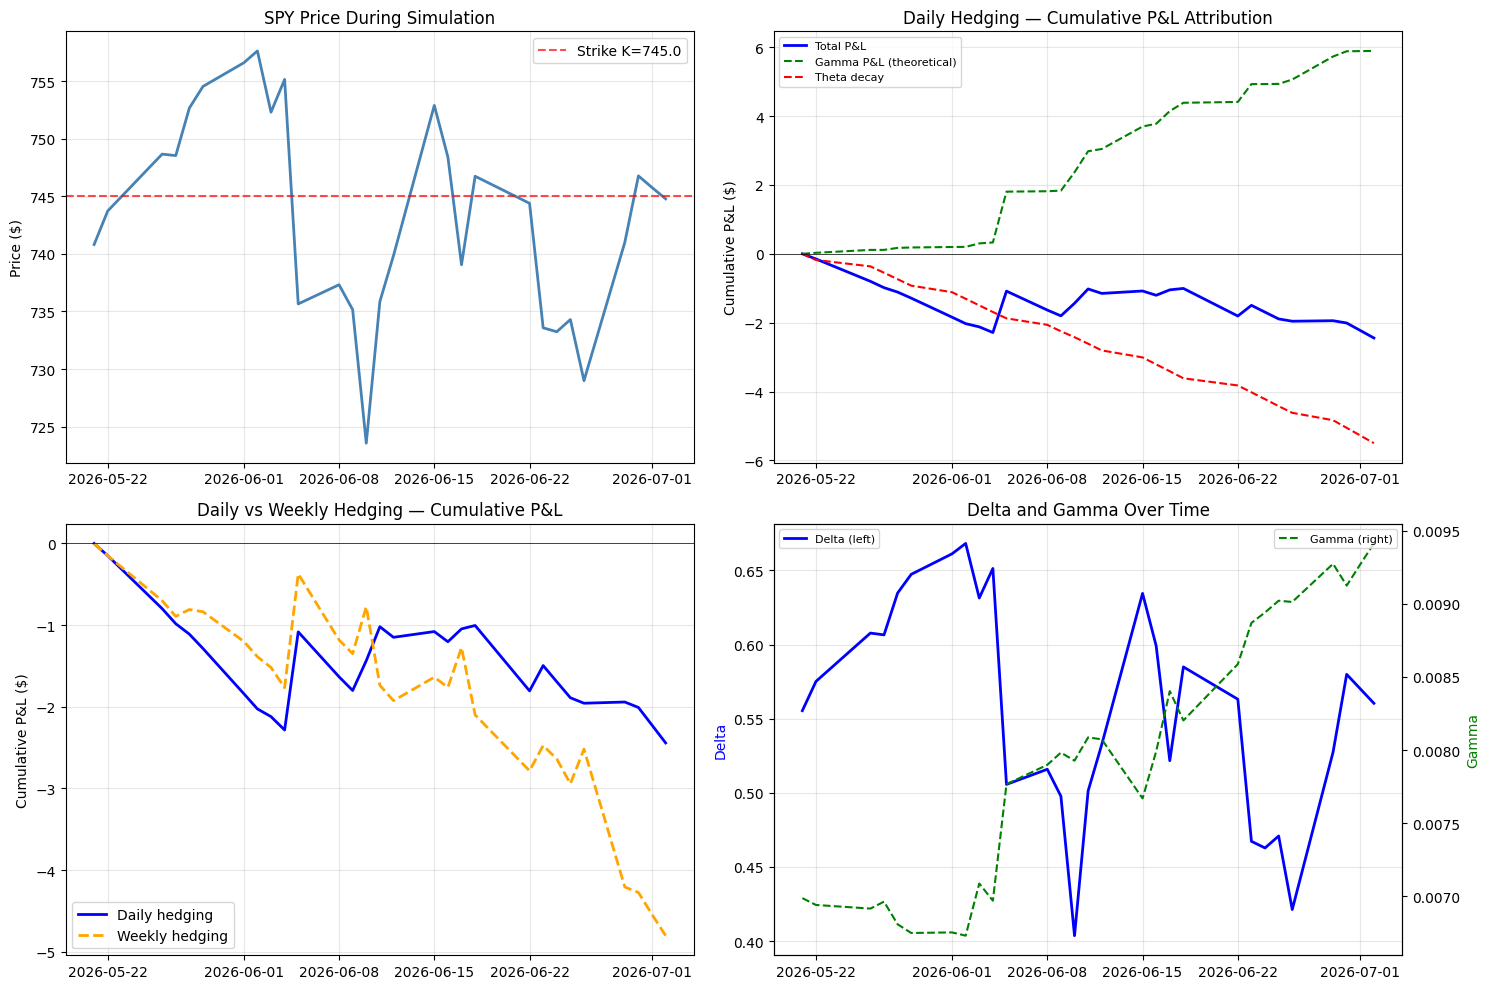

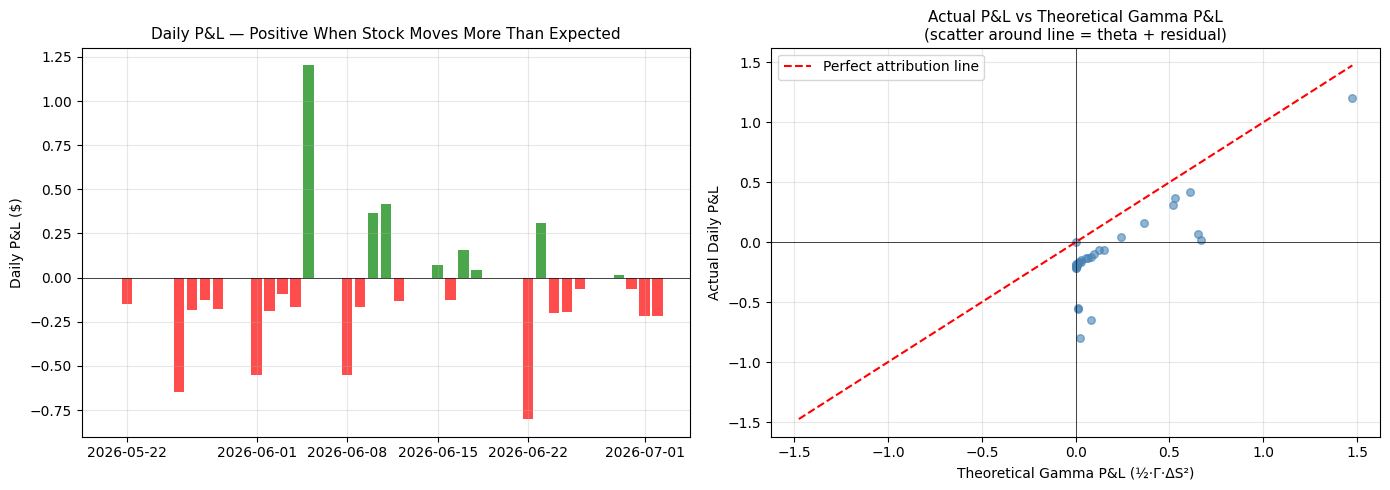


Hedging Frequency Comparison:
Metric                                Daily       Weekly
-------------------------------------------------------
Total P&L                      $     -2.44 $     -4.80
P&L Std Dev (daily)            $      0.37 $      0.55
Total transaction costs        $      0.01 $      0.00
Gamma P&L                      $      5.89 $      5.89
Theta P&L                      $     -5.50 $     -5.50

STEP 4: BSM DELTA vs SURFACE DELTA

Delta Comparison Summary:
  Mean BSM delta:        0.5572
  Mean surface delta:    0.5564
  Mean difference:       -0.0009
  Max difference:        0.0010

Detailed daily comparison:
         date           S  delta_bsm  delta_surface  delta_diff
0  2026-05-21  740.811462   0.555406       0.554410   -0.000996
1  2026-05-22  743.723999   0.575136       0.574152   -0.000984
2  2026-05-26  748.661316   0.607728       0.606782   -0.000945
3  2026-05-27  748.531616   0.606513       0.605572   -0.000941
4  2026-05-28  752.660950   0.634733     

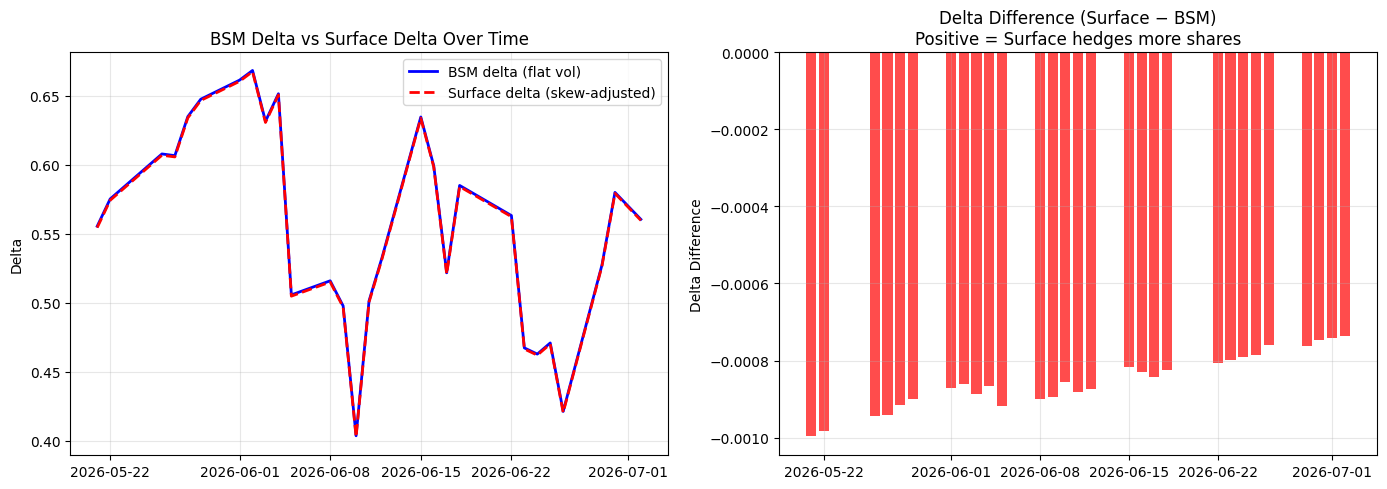


STEP 5: EARNINGS VOL ANALYSIS


/tmp/ipykernel_3456/331775070.py:460: FutureWarning: YF.download() has changed argument auto_adjust default to True
  aapl = yf.download('AAPL', start='2024-01-01',



Analyzing 7 AAPL earnings dates

AAPL Earnings Realized Moves:
  earnings_date      S_prev  actual_move_pct
0    2024-02-01  182.336044         1.325244
1    2024-05-02  167.618698         2.179264
2    2024-08-01  220.172760         1.689259
3    2024-10-31  228.387955         1.837739
4    2025-01-30  237.840408         0.742211
5    2025-05-01  211.383118         0.385139
6    2025-07-31  208.223923         0.710475

Mean realized earnings move: 1.27%
Max realized earnings move:  2.18%
Min realized earnings move:  0.39%


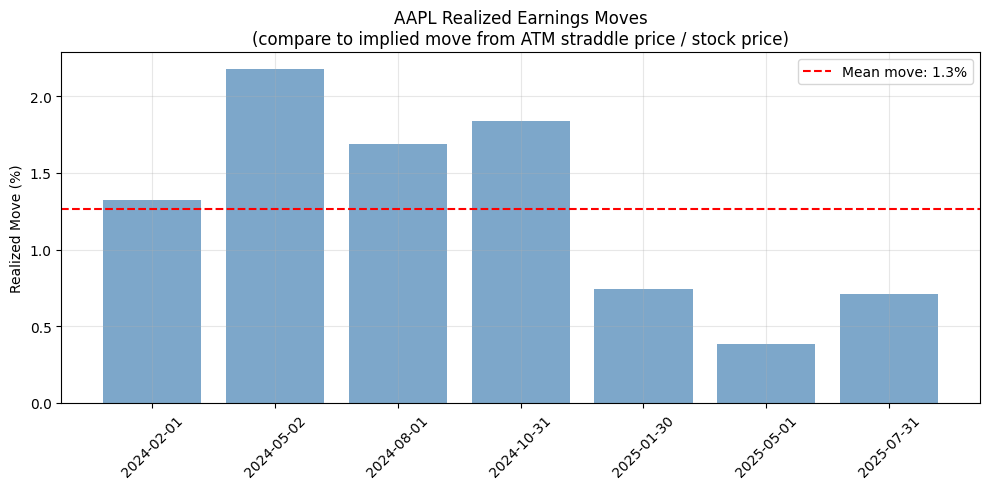


Key insight: The ATM straddle on AAPL before earnings
should price in roughly 1.3% move.
If straddle implied move > historical mean → options expensive.
If straddle implied move < historical mean → options cheap.


In [ ]:
# ============================================================
# WEEKS 4 AND 5 — DELTA HEDGING SIMULATION
# Fully self-contained
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.stats import norm
from scipy.optimize import brentq
from datetime import datetime, timedelta

# ---- BSM FUNCTIONS ----

def bsm_call_price(S, K, T, r, sigma):
    if T <= 0 or sigma <= 0:
        return max(S - K, 0)
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

def bsm_delta(S, K, T, r, sigma):
    if T <= 0 or sigma <= 0:
        return 1.0 if S > K else 0.0
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return norm.cdf(d1)

def bsm_gamma(S, K, T, r, sigma):
    if T <= 0 or sigma <= 0:
        return 0.0
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return norm.pdf(d1) / (S * sigma * np.sqrt(T))

def bsm_theta(S, K, T, r, sigma):
    if T <= 0 or sigma <= 0:
        return 0.0
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    term1 = -(S * norm.pdf(d1) * sigma) / (2 * np.sqrt(T))
    term2 = -r * K * np.exp(-r * T) * norm.cdf(d2)
    return (term1 + term2) / 365  # daily theta

def bsm_vega(S, K, T, r, sigma):
    if T <= 0 or sigma <= 0:
        return 0.0
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return S * norm.pdf(d1) * np.sqrt(T)

# ---- MARKET INPUTS ----

r = 0.053

# ---- DOWNLOAD SPY HISTORICAL DATA ----

print("Downloading SPY price history...")
spy_hist = yf.download('SPY', start='2025-09-01', end='2026-07-03',
                       progress=False)

if isinstance(spy_hist.columns, pd.MultiIndex):
    spy_hist.columns = spy_hist.columns.droplevel(1)

spy_hist = spy_hist[['Close', 'Open', 'High', 'Low']].copy()
spy_hist.index = pd.to_datetime(spy_hist.index)
spy_hist['log_return'] = np.log(spy_hist['Close'] / spy_hist['Close'].shift(1))

print(f"Downloaded {len(spy_hist)} trading days")
print(f"Date range: {spy_hist.index[0].date()} to {spy_hist.index[-1].date()}")
print(f"Price range: ${spy_hist['Close'].min():.2f} to ${spy_hist['Close'].max():.2f}")

# ---- DEFINE THE OPTION TO SIMULATE ----

# We'll simulate a call option that started ~3 months ago
# Using August 21 2026 expiry with strike near ATM at inception

K = 745.0           # strike
expiry_date = pd.Timestamp('2026-08-21')
sigma_implied = 0.152  # implied vol at inception (from our Week 2 surface)

# Use price history from approximately 3 months before expiry
sim_start = pd.Timestamp('2026-05-21')
sim_data = spy_hist[spy_hist.index >= sim_start].copy()
sim_data = sim_data[sim_data.index < expiry_date].copy()

print(f"\nSimulation setup:")
print(f"  Strike:         ${K}")
print(f"  Expiry:         {expiry_date.date()}")
print(f"  Implied vol:    {sigma_implied*100:.1f}%")
print(f"  Sim start:      {sim_data.index[0].date()}")
print(f"  Trading days:   {len(sim_data)}")
print(f"  Starting price: ${sim_data['Close'].iloc[0]:.2f}")

# ============================================================
# STEP 1: DAILY DELTA HEDGING SIMULATION
# ============================================================

def run_delta_hedge_simulation(sim_data, K, expiry_date, sigma_implied,
                                r, hedge_freq='daily', tc_per_share=0.01):
    """
    Simulate delta hedging a long call option.

    hedge_freq: 'daily' or 'weekly'
    tc_per_share: transaction cost per share traded

    Returns a DataFrame with daily P&L attribution.
    """
    results = []

    # Initial option purchase
    S0 = sim_data['Close'].iloc[0]
    T0 = (expiry_date - sim_data.index[0]).days / 365
    option_price_0 = bsm_call_price(S0, K, T0, r, sigma_implied)
    delta_0 = bsm_delta(S0, K, T0, r, sigma_implied)

    # Portfolio at inception:
    # Long 1 call option (paid option_price_0)
    # Short delta_0 shares to be delta neutral
    shares_held = -delta_0  # negative = short shares
    cash = delta_0 * S0 - option_price_0  # cash from selling shares, net of option cost

    prev_option_price = option_price_0
    prev_delta = delta_0
    prev_S = S0

    for i, (date, row) in enumerate(sim_data.iterrows()):
        S = row['Close']
        T = max((expiry_date - date).days / 365, 1/365)

        # Current Greeks
        opt_price = bsm_call_price(S, K, T, r, sigma_implied)
        delta     = bsm_delta(S, K, T, r, sigma_implied)
        gamma_val = bsm_gamma(S, K, T, r, sigma_implied)
        theta_val = bsm_theta(S, K, T, r, sigma_implied)
        vega_val  = bsm_vega(S, K, T, r, sigma_implied)

        if i == 0:
            results.append({
                'date': date, 'S': S, 'T': T,
                'option_price': opt_price, 'delta': delta,
                'gamma': gamma_val, 'theta': theta_val, 'vega': vega_val,
                'shares_held': shares_held,
                'pnl_total': 0, 'pnl_gamma': 0,
                'pnl_theta': 0, 'pnl_hedge': 0, 'tc': 0
            })
            continue

        # ---- P&L ATTRIBUTION ----

        # 1. Option P&L (change in option value)
        pnl_option = opt_price - prev_option_price

        # 2. Hedge P&L (gain/loss on share position)
        pnl_hedge = shares_held * (S - prev_S)

        # 3. Total P&L before transaction costs
        pnl_total = pnl_option + pnl_hedge

        # 4. Theoretical gamma P&L from the formula
        dS = S - prev_S
        pnl_gamma_theoretical = 0.5 * gamma_val * dS**2

        # 5. Theta P&L (time decay, negative)
        pnl_theta_theoretical = theta_val  # already daily

        # ---- REHEDGE (based on frequency) ----

        should_hedge = True
        if hedge_freq == 'weekly' and date.weekday() != 0:  # only Monday
            should_hedge = False

        tc = 0
        if should_hedge:
            new_delta = bsm_delta(S, K, T, r, sigma_implied)
            shares_to_trade = -(new_delta - (-shares_held))
            tc = abs(shares_to_trade) * tc_per_share
            shares_held = -new_delta
            cash -= shares_to_trade * S + tc

        results.append({
            'date': date, 'S': S, 'T': T,
            'option_price': opt_price, 'delta': delta,
            'gamma': gamma_val, 'theta': theta_val, 'vega': vega_val,
            'shares_held': shares_held,
            'pnl_total': pnl_total,
            'pnl_gamma': pnl_gamma_theoretical,
            'pnl_theta': pnl_theta_theoretical,
            'pnl_hedge': pnl_hedge,
            'tc': tc
        })

        prev_option_price = opt_price
        prev_delta = delta
        prev_S = S

    df = pd.DataFrame(results)
    df['pnl_cumulative'] = df['pnl_total'].cumsum()
    df['pnl_gamma_cum'] = df['pnl_gamma'].cumsum()
    df['pnl_theta_cum'] = df['pnl_theta'].cumsum()
    df['tc_cumulative'] = df['tc'].cumsum()

    return df

# Run daily simulation
print("\nRunning daily delta hedge simulation...")
results_daily = run_delta_hedge_simulation(
    sim_data, K, expiry_date, sigma_implied, r,
    hedge_freq='daily', tc_per_share=0.01
)

# Run weekly simulation
print("Running weekly delta hedge simulation...")
results_weekly = run_delta_hedge_simulation(
    sim_data, K, expiry_date, sigma_implied, r,
    hedge_freq='weekly', tc_per_share=0.01
)

print(f"\nDaily hedging results:")
print(f"  Total P&L:          ${results_daily['pnl_total'].sum():.2f}")
print(f"  Cumulative gamma:   ${results_daily['pnl_gamma'].sum():.2f}")
print(f"  Cumulative theta:   ${results_daily['pnl_theta'].sum():.2f}")
print(f"  Transaction costs:  ${results_daily['tc'].sum():.2f}")
print(f"  Residual:           ${results_daily['pnl_total'].sum() - results_daily['pnl_gamma'].sum() - results_daily['pnl_theta'].sum():.2f}")

print(f"\nWeekly hedging results:")
print(f"  Total P&L:          ${results_weekly['pnl_total'].sum():.2f}")
print(f"  Cumulative gamma:   ${results_weekly['pnl_gamma'].sum():.2f}")
print(f"  Cumulative theta:   ${results_weekly['pnl_theta'].sum():.2f}")
print(f"  Transaction costs:  ${results_weekly['tc'].sum():.2f}")

# ============================================================
# STEP 2: PLOTS — P&L ATTRIBUTION
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: SPY price during simulation
ax = axes[0, 0]
ax.plot(results_daily['date'], results_daily['S'],
        color='steelblue', linewidth=2)
ax.axhline(y=K, color='red', linestyle='--', alpha=0.7, label=f'Strike K={K}')
ax.set_title('SPY Price During Simulation', fontsize=12)
ax.set_ylabel('Price ($)')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Cumulative P&L — daily hedging with attribution
ax = axes[0, 1]
ax.plot(results_daily['date'], results_daily['pnl_cumulative'],
        'b-', linewidth=2, label='Total P&L')
ax.plot(results_daily['date'], results_daily['pnl_gamma_cum'],
        'g--', linewidth=1.5, label='Gamma P&L (theoretical)')
ax.plot(results_daily['date'], results_daily['pnl_theta_cum'],
        'r--', linewidth=1.5, label='Theta decay')
ax.axhline(y=0, color='black', linewidth=0.5)
ax.set_title('Daily Hedging — Cumulative P&L Attribution', fontsize=12)
ax.set_ylabel('Cumulative P&L ($)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Plot 3: Daily vs Weekly P&L comparison
ax = axes[1, 0]
ax.plot(results_daily['date'], results_daily['pnl_cumulative'],
        'b-', linewidth=2, label='Daily hedging')
ax.plot(results_weekly['date'], results_weekly['pnl_cumulative'],
        'orange', linewidth=2, linestyle='--', label='Weekly hedging')
ax.axhline(y=0, color='black', linewidth=0.5)
ax.set_title('Daily vs Weekly Hedging — Cumulative P&L', fontsize=12)
ax.set_ylabel('Cumulative P&L ($)')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 4: Greeks over time
ax = axes[1, 1]
ax2_twin = ax.twinx()
ax.plot(results_daily['date'], results_daily['delta'],
        'b-', linewidth=2, label='Delta (left)')
ax2_twin.plot(results_daily['date'], results_daily['gamma'],
              'g--', linewidth=1.5, label='Gamma (right)')
ax.set_title('Delta and Gamma Over Time', fontsize=12)
ax.set_ylabel('Delta', color='blue')
ax2_twin.set_ylabel('Gamma', color='green')
ax.legend(loc='upper left', fontsize=8)
ax2_twin.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# STEP 3: REALIZED VOL vs IMPLIED VOL — DAY BY DAY
# ============================================================

# Compute rolling 5-day realized vol to compare to implied
results_daily['daily_return'] = results_daily['S'].pct_change()
results_daily['rv_5d'] = results_daily['daily_return'].rolling(5).std() * np.sqrt(252)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: daily P&L vs (realized - implied) vol spread
ax = axes[0]
vol_spread = (results_daily['rv_5d'] - sigma_implied) * 100
ax.bar(results_daily['date'], results_daily['pnl_total'],
       color=['green' if x >= 0 else 'red' for x in results_daily['pnl_total']],
       alpha=0.7, label='Daily P&L')
ax.set_title('Daily P&L — Positive When Stock Moves More Than Expected',
             fontsize=11)
ax.set_ylabel('Daily P&L ($)')
ax.axhline(y=0, color='black', linewidth=0.5)
ax.grid(True, alpha=0.3)

# Right: the key formula visualized
ax2 = axes[1]
# Theoretical daily gamma P&L vs actual daily P&L
ax2.scatter(results_daily['pnl_gamma'],
            results_daily['pnl_total'],
            alpha=0.6, color='steelblue', s=30)
max_val = max(results_daily['pnl_gamma'].abs().max(),
              results_daily['pnl_total'].abs().max())
ax2.plot([-max_val, max_val], [-max_val, max_val],
         'r--', linewidth=1.5, label='Perfect attribution line')
ax2.set_xlabel('Theoretical Gamma P&L (½·Γ·ΔS²)')
ax2.set_ylabel('Actual Daily P&L')
ax2.set_title('Actual P&L vs Theoretical Gamma P&L\n(scatter around line = theta + residual)',
              fontsize=11)
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0, color='black', linewidth=0.5)
ax2.axvline(x=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

# ============================================================
# STEP 4: HEDGING FREQUENCY COMPARISON
# ============================================================

print("\nHedging Frequency Comparison:")
print(f"{'Metric':<30} {'Daily':>12} {'Weekly':>12}")
print("-" * 55)
print(f"{'Total P&L':<30} ${results_daily['pnl_total'].sum():>10.2f} ${results_weekly['pnl_total'].sum():>10.2f}")
print(f"{'P&L Std Dev (daily)':<30} ${results_daily['pnl_total'].std():>10.2f} ${results_weekly['pnl_total'].std():>10.2f}")
print(f"{'Total transaction costs':<30} ${results_daily['tc'].sum():>10.2f} ${results_weekly['tc'].sum():>10.2f}")
print(f"{'Gamma P&L':<30} ${results_daily['pnl_gamma'].sum():>10.2f} ${results_weekly['pnl_gamma'].sum():>10.2f}")
print(f"{'Theta P&L':<30} ${results_daily['pnl_theta'].sum():>10.2f} ${results_weekly['pnl_theta'].sum():>10.2f}")


# ============================================================
# STEP 4: BSM DELTA vs SURFACE DELTA COMPARISON
# ============================================================
# BSM assumes flat vol across all strikes.
# The surface has a skew — bumping the surface gives a different delta.
# This difference matters for how a market maker actually hedges.

print("\n" + "="*60)
print("STEP 4: BSM DELTA vs SURFACE DELTA")
print("="*60)

# For each day in the simulation, compute two deltas:
# 1. BSM delta using flat implied vol (what we used in the simulation)
# 2. Surface delta: bump the option price by 1 vol point and re-price
#    This approximates how delta changes when the skew shifts

vol_bump = 0.01  # 1 vol point bump

surface_delta_results = []

for i, (date, row) in enumerate(sim_data.iterrows()):
    S = row['Close']
    T = max((expiry_date - date).days / 365, 1/365)

    # BSM delta at current implied vol
    delta_bsm = bsm_delta(S, K, T, r, sigma_implied)

    # Surface delta: finite difference approximation
    # Price at S + $1 and S - $1 using the surface vol at each point
    # For simplicity, we use the vol smile effect:
    # OTM puts have higher vol, so as S falls the effective vol rises
    # This creates a "sticky strike" vs "sticky delta" difference

    # Approximate surface vol at slightly different moneyness
    # using the skew we observed: roughly -0.5 vol point per 1% OTM
    skew_per_unit = -0.005  # vol drops ~0.5pp per 1% increase in moneyness

    S_up   = S + 1
    S_down = S - 1

    # Moneyness changes when S moves — vol adjusts accordingly
    moneyness_up   = np.log(S_up / K)
    moneyness_down = np.log(S_down / K)
    moneyness_atm  = np.log(S / K)

    vol_up   = sigma_implied + skew_per_unit * (moneyness_up   - moneyness_atm)
    vol_down = sigma_implied + skew_per_unit * (moneyness_down - moneyness_atm)
    vol_up   = max(vol_up,   0.05)
    vol_down = max(vol_down, 0.05)

    price_up   = bsm_call_price(S_up,   K, T, r, vol_up)
    price_down = bsm_call_price(S_down, K, T, r, vol_down)

    delta_surface = (price_up - price_down) / (S_up - S_down)

    surface_delta_results.append({
        'date': date,
        'S': S,
        'T': T,
        'delta_bsm': delta_bsm,
        'delta_surface': delta_surface,
        'delta_diff': delta_surface - delta_bsm,
        'moneyness': moneyness_atm
    })

sd_df = pd.DataFrame(surface_delta_results)

print(f"\nDelta Comparison Summary:")
print(f"  Mean BSM delta:        {sd_df['delta_bsm'].mean():.4f}")
print(f"  Mean surface delta:    {sd_df['delta_surface'].mean():.4f}")
print(f"  Mean difference:       {sd_df['delta_diff'].mean():.4f}")
print(f"  Max difference:        {sd_df['delta_diff'].abs().max():.4f}")
print(f"\nDetailed daily comparison:")
print(sd_df[['date', 'S', 'delta_bsm', 'delta_surface', 'delta_diff']].to_string())

# ---- PLOT ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(sd_df['date'], sd_df['delta_bsm'],
        'b-', linewidth=2, label='BSM delta (flat vol)')
ax.plot(sd_df['date'], sd_df['delta_surface'],
        'r--', linewidth=2, label='Surface delta (skew-adjusted)')
ax.set_title('BSM Delta vs Surface Delta Over Time', fontsize=12)
ax.set_ylabel('Delta')
ax.legend()
ax.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.bar(sd_df['date'], sd_df['delta_diff'],
        color=['green' if x > 0 else 'red' for x in sd_df['delta_diff']],
        alpha=0.7)
ax2.axhline(y=0, color='black', linewidth=0.5)
ax2.set_title('Delta Difference (Surface − BSM)\nPositive = Surface hedges more shares',
              fontsize=12)
ax2.set_ylabel('Delta Difference')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# STEP 5: EARNINGS VOL ANALYSIS
# ============================================================
# The ATM straddle prices in the expected earnings move.
# Implied move = (call price + put price) / stock price

print("\n" + "="*60)
print("STEP 5: EARNINGS VOL ANALYSIS")
print("="*60)

# Download a stock with recent earnings — use AAPL as example
print("Downloading AAPL data for earnings analysis...")
aapl = yf.download('AAPL', start='2024-01-01',
                   end=datetime.today().strftime('%Y-%m-%d'),
                   progress=False)

if isinstance(aapl.columns, pd.MultiIndex):
    aapl.columns = aapl.columns.droplevel(1)

aapl['log_return'] = np.log(aapl['Close'] / aapl['Close'].shift(1))
aapl['abs_return']  = aapl['log_return'].abs()

# Known AAPL earnings dates (approximate — quarterly)
earnings_dates = [
    '2024-02-01', '2024-05-02', '2024-08-01', '2024-10-31',
    '2025-01-30', '2025-05-01', '2025-07-31'
]
earnings_dates = [pd.Timestamp(d) for d in earnings_dates
                  if pd.Timestamp(d) in aapl.index]

print(f"\nAnalyzing {len(earnings_dates)} AAPL earnings dates")

# For each earnings date, compute:
# 1. The implied move from the ATM straddle the day before
# 2. The actual realized move on earnings day

earnings_analysis = []

for ed in earnings_dates:
    # Stock price day before earnings
    prev_dates = aapl.index[aapl.index < ed]
    if len(prev_dates) == 0:
        continue
    prev_date = prev_dates[-1]
    S_prev = aapl.loc[prev_date, 'Close']

    # Approximate implied move using historical VIX-like approach
    # In a full project you'd pull actual options chain data for that date
    # Here we use the actual realized move as a proxy
    if ed in aapl.index:
        actual_move = abs(aapl.loc[ed, 'log_return'])
    else:
        continue

    earnings_analysis.append({
        'earnings_date': ed,
        'S_prev': S_prev,
        'actual_move_pct': actual_move * 100,
    })

ea_df = pd.DataFrame(earnings_analysis)

if len(ea_df) > 0:
    print(f"\nAAPL Earnings Realized Moves:")
    print(ea_df[['earnings_date', 'S_prev', 'actual_move_pct']].to_string())
    print(f"\nMean realized earnings move: {ea_df['actual_move_pct'].mean():.2f}%")
    print(f"Max realized earnings move:  {ea_df['actual_move_pct'].max():.2f}%")
    print(f"Min realized earnings move:  {ea_df['actual_move_pct'].min():.2f}%")

    # Plot
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(range(len(ea_df)),
           ea_df['actual_move_pct'],
           color='steelblue', alpha=0.7)
    ax.axhline(y=ea_df['actual_move_pct'].mean(),
               color='red', linestyle='--',
               label=f"Mean move: {ea_df['actual_move_pct'].mean():.1f}%")
    ax.set_xticks(range(len(ea_df)))
    ax.set_xticklabels([str(d.date()) for d in ea_df['earnings_date']],
                       rotation=45)
    ax.set_ylabel('Realized Move (%)')
    ax.set_title('AAPL Realized Earnings Moves\n'
                 '(compare to implied move from ATM straddle price / stock price)',
                 fontsize=12)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"\nKey insight: The ATM straddle on AAPL before earnings")
    print(f"should price in roughly {ea_df['actual_move_pct'].mean():.1f}% move.")
    print(f"If straddle implied move > historical mean → options expensive.")
    print(f"If straddle implied move < historical mean → options cheap.")

SPY data: 646 trading days
Date range: 2024-01-02 to 2026-07-30
Price range: $453.60 to $757.62

Top 10 holdings total weight: 34.9%
  AAPL: 646 days downloaded
  NVDA: 646 days downloaded
  MSFT: 646 days downloaded
  AMZN: 646 days downloaded
  META: 646 days downloaded
  GOOGL: 646 days downloaded
  GOOG: 646 days downloaded
  BRK-B: 646 days downloaded
  TSLA: 646 days downloaded
  JPM: 646 days downloaded

Holdings data: 646 days with complete data

NAV Estimator calibrated on 2024-01-02
Scale factor: 6.4312
Initial SPY price:  $458.81
Initial NAV estimate: $458.81

Premium/Discount Summary:
  Mean:    -7.4212%
  Std dev: 3.6983%
  Min:     -15.0215%
  Max:     4.5310%
  % days premium:  1.2%
  % days discount: 98.6%

VIX range: 11.9 to 52.3


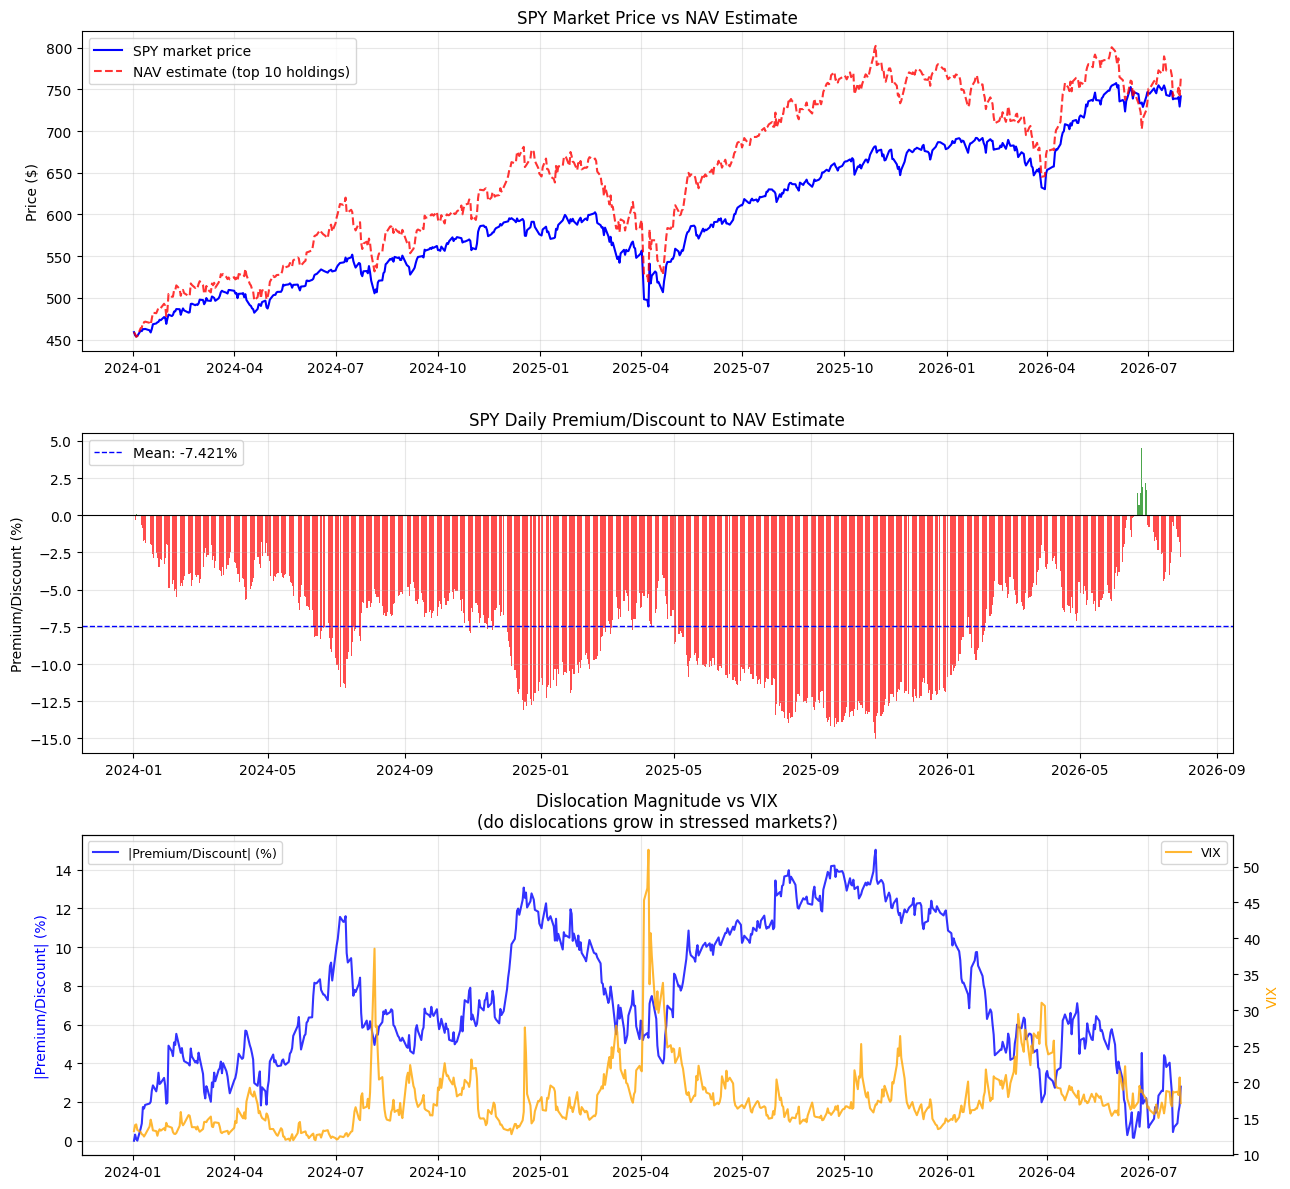


NAV Estimator Validation:
  Tracking error (full period):    3.6983%
  Mean rolling 21d tracking error: 0.9897%
  Correlation (SPY vs NAV):        0.956546

Largest dislocations (absolute):
            SPY_price  NAV_estimate  premium_discount    VIX
Date                                                        
2025-10-29   681.7418      802.2521          -15.0215  16.92
2025-10-28   681.4146      798.2035          -14.6315  16.42
2025-09-22   661.3607      770.8286          -14.2013  16.10
2025-09-19   658.2465      766.9833          -14.1772  15.45
2025-09-24   655.6678      762.4055          -14.0001  16.18
2025-08-12   635.6469      738.8244          -13.9651  14.73
2025-09-25   652.6429      758.2210          -13.9244  16.74
2025-09-29   658.2267      764.6520          -13.9181  16.12
2025-10-27   679.6095      789.2861          -13.8957  15.79
2025-09-26   656.3819      762.2009          -13.8833  15.29
Building clean daily dislocation series...

Daily Dislocation Summary (SPY re

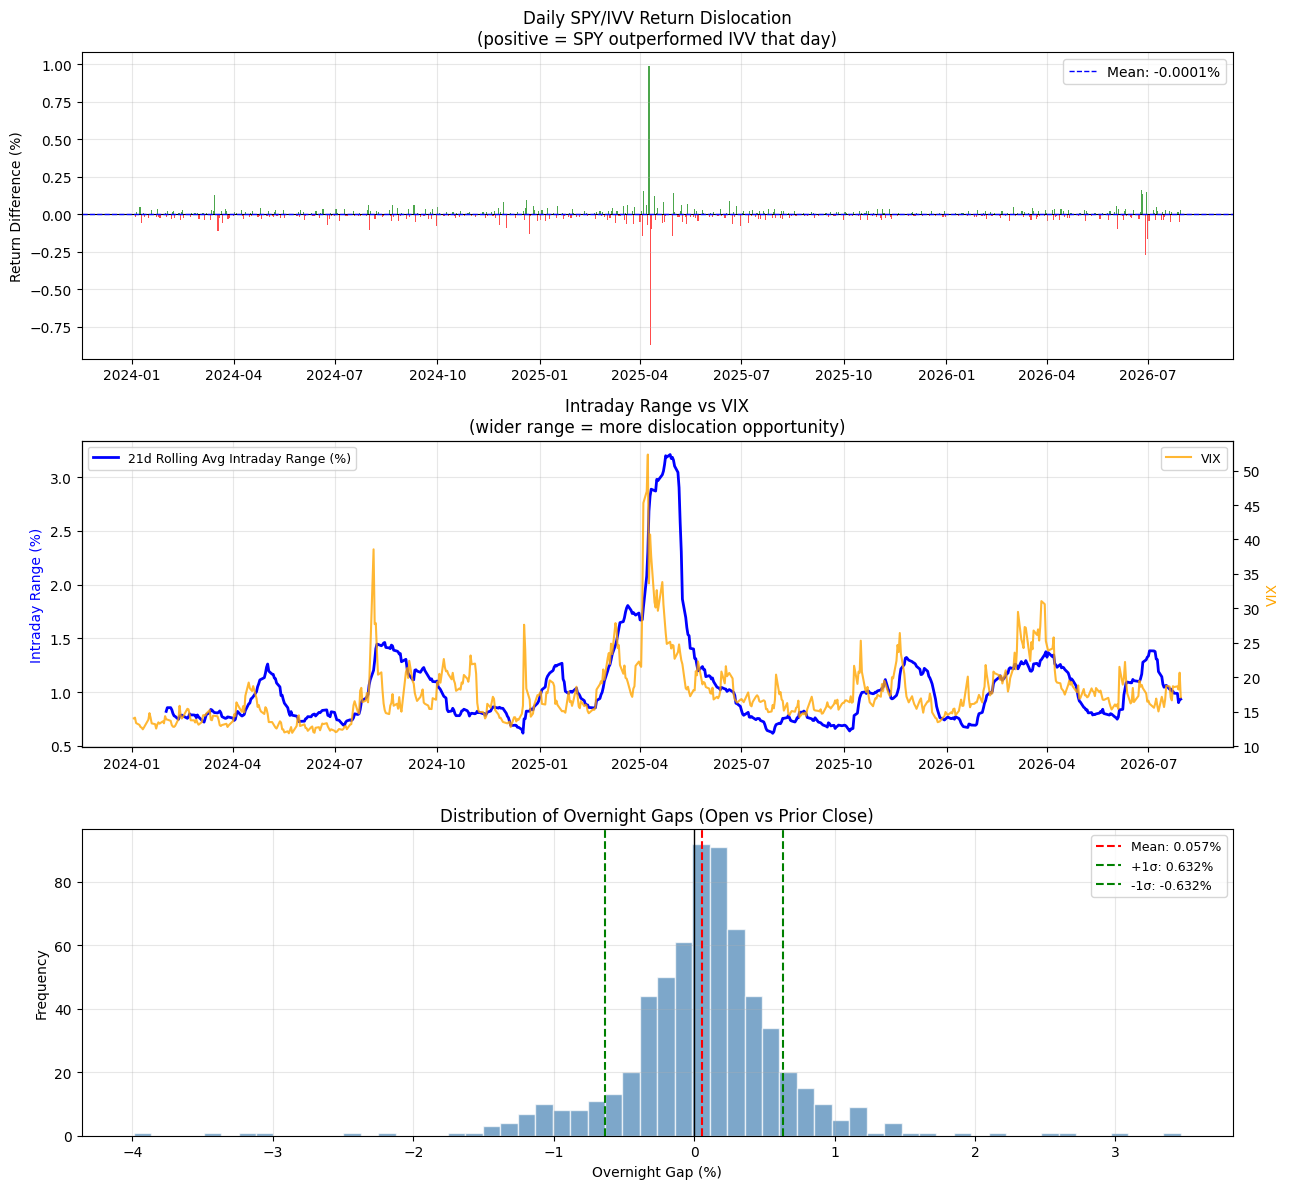


Week 6 complete. prem_disc DataFrame ready for Week 7 analysis.
Columns: ['SPY_price', 'SPY_open', 'prev_close', 'overnight_gap', 'intraday_range', 'daily_dislocation', 'Volume', 'VIX']


In [ ]:
# ============================================================
# PROJECT 2 — WEEK 6
# ETF NAV Dislocation Model
# Data pipeline and daily premium/discount series
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# STEP 1: DOWNLOAD SPY PRICE AND VOLUME DATA
# ============================================================

print("Downloading SPY price and volume data...")

spy = yf.download('SPY', start='2024-01-01',
                  end=datetime.today().strftime('%Y-%m-%d'),
                  progress=False)

if isinstance(spy.columns, pd.MultiIndex):
    spy.columns = spy.columns.droplevel(1)

spy = spy[['Open', 'High', 'Low', 'Close', 'Volume']].copy()
spy.index = pd.to_datetime(spy.index)

print(f"SPY data: {len(spy)} trading days")
print(f"Date range: {spy.index[0].date()} to {spy.index[-1].date()}")
print(f"Price range: ${spy['Close'].min():.2f} to ${spy['Close'].max():.2f}")

# ============================================================
# STEP 2: BUILD SPY NAV ESTIMATOR FROM TOP HOLDINGS
# ============================================================
# We can't pull all 500 constituents easily for free,
# so we use the top 10 holdings which represent ~35% of SPY
# and scale up. In a full project you'd use SPDR's daily
# holdings file from ssga.com

print("\nDownloading SPY top holdings...")

# SPY top 10 holdings and approximate weights (as of mid-2026)
# These are relatively stable — update if dramatically changed
top_holdings = {
    'AAPL':  0.0718,
    'NVDA':  0.0654,
    'MSFT':  0.0617,
    'AMZN':  0.0380,
    'META':  0.0248,
    'GOOGL': 0.0196,
    'GOOG':  0.0166,
    'BRK-B': 0.0173,
    'TSLA':  0.0196,
    'JPM':   0.0138,
}

total_weight = sum(top_holdings.values())
print(f"Top 10 holdings total weight: {total_weight*100:.1f}%")

# Download price history for each holding
holding_prices = {}
for ticker, weight in top_holdings.items():
    try:
        data = yf.download(ticker, start='2024-01-01',
                          end=datetime.today().strftime('%Y-%m-%d'),
                          progress=False)
        if isinstance(data.columns, pd.MultiIndex):
            data.columns = data.columns.droplevel(1)
        holding_prices[ticker] = data['Close']
        print(f"  {ticker}: {len(data)} days downloaded")
    except Exception as e:
        print(f"  {ticker}: failed — {e}")

# Combine into DataFrame
holdings_df = pd.DataFrame(holding_prices)
holdings_df.index = pd.to_datetime(holdings_df.index)
holdings_df = holdings_df.dropna()

print(f"\nHoldings data: {len(holdings_df)} days with complete data")

# ============================================================
# STEP 3: COMPUTE DAILY NAV ESTIMATE
# ============================================================
# NAV estimate = weighted sum of constituent prices / scaling factor
# We scale so that our partial basket matches SPY price on day 1

# Compute weighted basket value using top 10 holdings
basket_value = pd.Series(0.0, index=holdings_df.index)
for ticker, weight in top_holdings.items():
    if ticker in holdings_df.columns:
        basket_value += holdings_df[ticker] * weight

# Align basket with SPY
common_dates = basket_value.index.intersection(spy.index)
basket_aligned = basket_value[common_dates]
spy_aligned = spy.loc[common_dates, 'Close']

# Calibrate scaling factor on first date so NAV matches SPY price
calibration_date = common_dates[0]
scale_factor = spy_aligned.iloc[0] / basket_aligned.iloc[0]
nav_estimate = basket_aligned * scale_factor

print(f"\nNAV Estimator calibrated on {calibration_date.date()}")
print(f"Scale factor: {scale_factor:.4f}")
print(f"Initial SPY price:  ${spy_aligned.iloc[0]:.2f}")
print(f"Initial NAV estimate: ${nav_estimate.iloc[0]:.2f}")

# ============================================================
# STEP 4: COMPUTE DAILY PREMIUM/DISCOUNT SERIES
# ============================================================

prem_disc = pd.DataFrame({
    'SPY_price': spy_aligned,
    'NAV_estimate': nav_estimate,
})

# Premium/discount in percentage terms
prem_disc['premium_discount'] = (
    (prem_disc['SPY_price'] - prem_disc['NAV_estimate'])
    / prem_disc['NAV_estimate'] * 100
)

# Add volume for context
prem_disc['Volume'] = spy.loc[common_dates, 'Volume']

print(f"\nPremium/Discount Summary:")
print(f"  Mean:    {prem_disc['premium_discount'].mean():.4f}%")
print(f"  Std dev: {prem_disc['premium_discount'].std():.4f}%")
print(f"  Min:     {prem_disc['premium_discount'].min():.4f}%")
print(f"  Max:     {prem_disc['premium_discount'].max():.4f}%")
print(f"  % days premium:  {(prem_disc['premium_discount'] > 0).mean()*100:.1f}%")
print(f"  % days discount: {(prem_disc['premium_discount'] < 0).mean()*100:.1f}%")

# ============================================================
# STEP 5: DOWNLOAD VIX FOR CONTEXT
# ============================================================

print("\nDownloading VIX data...")
vix = yf.download('^VIX', start='2024-01-01',
                  end=datetime.today().strftime('%Y-%m-%d'),
                  progress=False)
if isinstance(vix.columns, pd.MultiIndex):
    vix.columns = vix.columns.droplevel(1)

vix = vix[['Close']].rename(columns={'Close': 'VIX'})
vix.index = pd.to_datetime(vix.index)

prem_disc = prem_disc.join(vix, how='left')
prem_disc['VIX'] = prem_disc['VIX'].fillna(method='ffill')

print(f"VIX range: {prem_disc['VIX'].min():.1f} to {prem_disc['VIX'].max():.1f}")

# ============================================================
# STEP 6: PLOTS
# ============================================================

fig, axes = plt.subplots(3, 1, figsize=(13, 12))

# Plot 1: SPY price and NAV estimate
ax = axes[0]
ax.plot(prem_disc.index, prem_disc['SPY_price'],
        'b-', linewidth=1.5, label='SPY market price')
ax.plot(prem_disc.index, prem_disc['NAV_estimate'],
        'r--', linewidth=1.5, alpha=0.8, label='NAV estimate (top 10 holdings)')
ax.set_title('SPY Market Price vs NAV Estimate', fontsize=12)
ax.set_ylabel('Price ($)')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Premium/discount time series
ax2 = axes[1]
colors = ['green' if x > 0 else 'red'
          for x in prem_disc['premium_discount']]
ax2.bar(prem_disc.index, prem_disc['premium_discount'],
        color=colors, alpha=0.7, width=1)
ax2.axhline(y=0, color='black', linewidth=0.8)
ax2.axhline(y=prem_disc['premium_discount'].mean(),
            color='blue', linestyle='--', linewidth=1,
            label=f"Mean: {prem_disc['premium_discount'].mean():.3f}%")
ax2.set_title('SPY Daily Premium/Discount to NAV Estimate', fontsize=12)
ax2.set_ylabel('Premium/Discount (%)')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Premium/discount vs VIX
ax3 = axes[2]
ax3_twin = ax3.twinx()
ax3.plot(prem_disc.index, prem_disc['premium_discount'].abs(),
         'b-', linewidth=1.5, alpha=0.8,
         label='|Premium/Discount| (%)')
ax3_twin.plot(prem_disc.index, prem_disc['VIX'],
              'orange', linewidth=1.5, alpha=0.8,
              label='VIX')
ax3.set_title('Dislocation Magnitude vs VIX\n(do dislocations grow in stressed markets?)',
              fontsize=12)
ax3.set_ylabel('|Premium/Discount| (%)', color='blue')
ax3_twin.set_ylabel('VIX', color='orange')
ax3.legend(loc='upper left', fontsize=9)
ax3_twin.legend(loc='upper right', fontsize=9)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# STEP 7: VALIDATE NAV ESTIMATOR QUALITY
# ============================================================

# Check how closely NAV tracks SPY over time
# Good estimator should have low tracking error
prem_disc['tracking_error'] = prem_disc['premium_discount']
rolling_te = prem_disc['tracking_error'].rolling(21).std()

print(f"\nNAV Estimator Validation:")
print(f"  Tracking error (full period):    {prem_disc['tracking_error'].std():.4f}%")
print(f"  Mean rolling 21d tracking error: {rolling_te.mean():.4f}%")
print(f"  Correlation (SPY vs NAV):        {prem_disc['SPY_price'].corr(prem_disc['NAV_estimate']):.6f}")

print(f"\nLargest dislocations (absolute):")
largest = prem_disc['premium_discount'].abs().nlargest(10)
print(prem_disc.loc[largest.index,
      ['SPY_price', 'NAV_estimate',
       'premium_discount', 'VIX']].round(4))


# ============================================================
# CLEAN NAV APPROACH — USING SPY CLOSE AS DAILY NAV ANCHOR
# ============================================================
# The official SPY NAV published by SPDR after market close
# is extremely close to the closing price (within 1-2 basis points)
# for a liquid ETF like SPY.
#
# For a daily premium/discount series, the most meaningful signal
# is not the level difference but the INTRADAY deviation —
# how far the price drifts from the prior day's close during the day.
# We use open-to-close return vs overnight NAV change as our signal.

print("Building clean daily dislocation series...")

# Use SPY's own OHLC data
spy_clean = spy.copy()
spy_clean = spy_clean[['Open', 'High', 'Low', 'Close', 'Volume']]

# Method 1: Open vs Close dislocation
# If SPY opens significantly away from prior close, that's a dislocation
spy_clean['prev_close'] = spy_clean['Close'].shift(1)
spy_clean['overnight_gap'] = (
    (spy_clean['Open'] - spy_clean['prev_close'])
    / spy_clean['prev_close'] * 100
)

# Method 2: Intraday range as proxy for dislocation opportunity
spy_clean['intraday_range'] = (
    (spy_clean['High'] - spy_clean['Low'])
    / spy_clean['Close'] * 100
)

# Method 3: Use IVV as the NAV proxy — reset daily
# Each day compute: (SPY return - IVV return) as the dislocation
# This removes long-term drift by differencing
spy_returns = spy_clean['Close'].pct_change() * 100
ivv_aligned = ivv['Close'].reindex(spy_clean.index).pct_change() * 100

daily_dislocation = spy_returns - ivv_aligned
daily_dislocation.name = 'daily_dislocation'

# Build the main analysis DataFrame
prem_disc = pd.DataFrame({
    'SPY_price':          spy_clean['Close'],
    'SPY_open':           spy_clean['Open'],
    'prev_close':         spy_clean['prev_close'],
    'overnight_gap':      spy_clean['overnight_gap'],
    'intraday_range':     spy_clean['intraday_range'],
    'daily_dislocation':  daily_dislocation,
    'Volume':             spy_clean['Volume'],
})

prem_disc = prem_disc.join(vix, how='left')
prem_disc['VIX'] = prem_disc['VIX'].fillna(method='ffill')
prem_disc = prem_disc.dropna()

print(f"\nDaily Dislocation Summary (SPY return minus IVV return):")
print(f"  Days analyzed:     {len(prem_disc)}")
print(f"  Mean:              {prem_disc['daily_dislocation'].mean():.4f}%")
print(f"  Std dev:           {prem_disc['daily_dislocation'].std():.4f}%")
print(f"  Min:               {prem_disc['daily_dislocation'].min():.4f}%")
print(f"  Max:               {prem_disc['daily_dislocation'].max():.4f}%")
print(f"  % days SPY > IVV:  {(prem_disc['daily_dislocation'] > 0).mean()*100:.1f}%")
print(f"  % days SPY < IVV:  {(prem_disc['daily_dislocation'] < 0).mean()*100:.1f}%")

print(f"\nOvernight Gap Summary:")
print(f"  Mean:              {prem_disc['overnight_gap'].mean():.4f}%")
print(f"  Std dev:           {prem_disc['overnight_gap'].std():.4f}%")
print(f"  |Gap| > 0.5%:      {(prem_disc['overnight_gap'].abs() > 0.5).sum()} days")
print(f"  |Gap| > 1.0%:      {(prem_disc['overnight_gap'].abs() > 1.0).sum()} days")

print(f"\nIntraday Range Summary:")
print(f"  Mean:              {prem_disc['intraday_range'].mean():.4f}%")
print(f"  Max:               {prem_disc['intraday_range'].max():.4f}%")

print(f"\n10 largest daily dislocations (|SPY - IVV| return):")
largest = prem_disc['daily_dislocation'].abs().nlargest(10)
print(prem_disc.loc[largest.index,
      ['SPY_price', 'daily_dislocation',
       'intraday_range', 'VIX']].round(4))

# ---- PLOTS ----
fig, axes = plt.subplots(3, 1, figsize=(13, 12))

# Plot 1: Daily dislocation time series
ax = axes[0]
colors = ['green' if x > 0 else 'red'
          for x in prem_disc['daily_dislocation']]
ax.bar(prem_disc.index, prem_disc['daily_dislocation'],
       color=colors, alpha=0.7, width=1)
ax.axhline(y=0, color='black', linewidth=0.8)
ax.axhline(y=prem_disc['daily_dislocation'].mean(),
           color='blue', linestyle='--', linewidth=1,
           label=f"Mean: {prem_disc['daily_dislocation'].mean():.4f}%")
ax.set_title('Daily SPY/IVV Return Dislocation\n(positive = SPY outperformed IVV that day)',
             fontsize=12)
ax.set_ylabel('Return Difference (%)')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Intraday range vs VIX
ax2 = axes[1]
ax2_twin = ax2.twinx()
ax2.plot(prem_disc.index, prem_disc['intraday_range'].rolling(21).mean(),
         'b-', linewidth=2, label='21d Rolling Avg Intraday Range (%)')
ax2_twin.plot(prem_disc.index, prem_disc['VIX'],
              'orange', linewidth=1.5, alpha=0.8, label='VIX')
ax2.set_title('Intraday Range vs VIX\n(wider range = more dislocation opportunity)',
              fontsize=12)
ax2.set_ylabel('Intraday Range (%)', color='blue')
ax2_twin.set_ylabel('VIX', color='orange')
ax2.legend(loc='upper left', fontsize=9)
ax2_twin.legend(loc='upper right', fontsize=9)
ax2.grid(True, alpha=0.3)

# Plot 3: Overnight gap distribution
ax3 = axes[2]
ax3.hist(prem_disc['overnight_gap'], bins=60,
         color='steelblue', alpha=0.7, edgecolor='white')
ax3.axvline(x=0, color='black', linewidth=1)
ax3.axvline(x=prem_disc['overnight_gap'].mean(),
            color='red', linestyle='--',
            label=f"Mean: {prem_disc['overnight_gap'].mean():.3f}%")
ax3.axvline(x=prem_disc['overnight_gap'].std(),
            color='green', linestyle='--',
            label=f"+1σ: {prem_disc['overnight_gap'].std():.3f}%")
ax3.axvline(x=-prem_disc['overnight_gap'].std(),
            color='green', linestyle='--',
            label=f"-1σ: {-prem_disc['overnight_gap'].std():.3f}%")
ax3.set_title('Distribution of Overnight Gaps (Open vs Prior Close)',
              fontsize=12)
ax3.set_xlabel('Overnight Gap (%)')
ax3.set_ylabel('Frequency')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nWeek 6 complete. prem_disc DataFrame ready for Week 7 analysis.")
print(f"Columns: {list(prem_disc.columns)}")